In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/merged/dataset_zone_1.csv")
df.head()

,ts,outside_temperature,inside_temperature,outside_humidity,inside_humidity,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,soil_temperature_0-7cm,soil_temperature_7-18cm,ec,ph,soil_moisture,irrigation_duration_minutes,liters_total
0,2025-02-09 00:00:00,NaN,NaN,NaN,NaN,5.7775,91.0,0.0,1025.785000,5.960000,0.0,7.670000,10.785000,NaN,NaN,NaN,0,0.0
1,2025-02-09 00:10:00,NaN,NaN,NaN,NaN,5.7275,91.0,0.0,1025.751667,6.093333,0.0,7.603333,10.751667,NaN,NaN,NaN,0,0.0
2,2025-02-09 00:20:00,NaN,NaN,NaN,NaN,5.6775,91.0,0.0,1025.718333,6.226667,0.0,7.536667,10.718333,NaN,NaN,NaN,0,0.0
3,2025-02-09 00:30:00,NaN,NaN,NaN,NaN,5.6275,91.0,0.0,1025.685000,6.360000,0.0,7.470000,10.685000,NaN,NaN,NaN,0,0.0
4,2025-02-09 00:40:00,NaN,NaN,NaN,NaN,5.5775,91.0,0.0,1025.651667,6.493333,0.0,7.403333,10.651667,NaN,NaN,NaN,0,0.0


In [3]:
df.shape


(33259, 18)

In [4]:
df.columns

Index(['ts', 'outside_temperature', 'inside_temperature', 'outside_humidity',
       'inside_humidity', 'weather_temp', 'weather_humidity', 'weather_rain',
       'weather_pressure', 'weather_wind_speed', 'weather_radiation',
       'soil_temperature_0-7cm', 'soil_temperature_7-18cm', 'ec', 'ph',
       'soil_moisture', 'irrigation_duration_minutes', 'liters_total'],
      dtype='str')

In [5]:
df.dtypes

ts                                 str
outside_temperature            float64
inside_temperature             float64
outside_humidity               float64
inside_humidity                float64
weather_temp                   float64
weather_humidity               float64
weather_rain                   float64
weather_pressure               float64
weather_wind_speed             float64
weather_radiation              float64
soil_temperature_0-7cm         float64
soil_temperature_7-18cm        float64
ec                             float64
ph                             float64
soil_moisture                  float64
irrigation_duration_minutes      int64
liters_total                   float64
dtype: object

In [6]:
df.isna().sum()

ts                                 0
outside_temperature            31174
inside_temperature             24316
outside_humidity               31167
inside_humidity                24317
weather_temp                       0
weather_humidity                   0
weather_rain                       0
weather_pressure                   0
weather_wind_speed                 0
weather_radiation                  0
soil_temperature_0-7cm             0
soil_temperature_7-18cm            0
ec                             18177
ph                              5701
soil_moisture                  22516
irrigation_duration_minutes        0
liters_total                       0
dtype: int64

In [7]:
df.isna().mean()*100

ts                              0.000000
outside_temperature            93.731020
inside_temperature             73.111038
outside_humidity               93.709973
inside_humidity                73.114044
weather_temp                    0.000000
weather_humidity                0.000000
weather_rain                    0.000000
weather_pressure                0.000000
weather_wind_speed              0.000000
weather_radiation               0.000000
soil_temperature_0-7cm          0.000000
soil_temperature_7-18cm         0.000000
ec                             54.652876
ph                             17.141225
soil_moisture                  67.698969
irrigation_duration_minutes     0.000000
liters_total                    0.000000
dtype: float64

In [8]:
df["irrigation_duration_minutes"].value_counts()

irrigation_duration_minutes
0     32541
10      558
7        32
9        30
1        20
8        18
6        15
2        12
4        11
3        11
5        11
Name: count, dtype: int64

In [9]:
(df["irrigation_duration_minutes"] > 0).value_counts()

irrigation_duration_minutes
False    32541
True       718
Name: count, dtype: int64

In [10]:
df[df["irrigation_duration_minutes"] > 0][
    ["ts", "irrigation_duration_minutes", "liters_total"]
].head(20)

,ts,irrigation_duration_minutes,liters_total
1908,2025-02-22 06:00:00,9,9.9
1909,2025-02-22 06:10:00,7,7.7
3411,2025-03-04 16:30:00,8,8.8
3412,2025-03-04 16:40:00,10,11.0
3413,2025-03-04 16:50:00,10,11.0
3414,2025-03-04 17:00:00,10,11.0
3415,2025-03-04 17:10:00,10,11.0
3416,2025-03-04 17:20:00,10,11.0
3417,2025-03-04 17:30:00,10,11.0
3418,2025-03-04 17:40:00,10,11.0


In [11]:
events = pd.read_csv("../data/irrigation_events/final_irrigation_events.csv")
events.head()

,sector,start,end,initial_humidity,final_humidity,stop_reason,type,duration_hours
0,1,2025-02-22 06:01:00,2025-02-22 06:16:00,28,28,fertigation_timeout,fertigation,0.25
1,1,2025-03-04 16:32:00,2025-03-04 18:00:00,46,46,time_restriction,standard_irrigation,1.47
2,1,2025-03-10 15:58:00,2025-03-10 16:33:00,44,41,physical_valve_closure,standard_irrigation,0.58
3,1,2025-04-07 06:07:00,2025-04-07 06:28:00,44,41,fertigation_timeout,fertigation,0.35
4,1,2025-04-11 06:01:00,2025-04-11 06:16:00,42,39,fertigation_timeout,fertigation,0.25


In [12]:
events.shape

(789, 8)

In [13]:
events.dtypes

sector                int64
start                   str
end                     str
initial_humidity      int64
final_humidity        int64
stop_reason             str
type                    str
duration_hours      float64
dtype: object

In [14]:
events.columns

Index(['sector', 'start', 'end', 'initial_humidity', 'final_humidity',
       'stop_reason', 'type', 'duration_hours'],
      dtype='str')

In [15]:
events_zone1 = events[events["sector"]== 1]
events_zone1.shape

(87, 8)

In [16]:
events_zone1["type"].value_counts()

type
standard_irrigation    45
fertigation            42
Name: count, dtype: int64

In [17]:
events_zone1["stop_reason"].value_counts()

stop_reason
fertigation_timeout       45
physical_valve_closure    24
time_restriction          10
humidity_threshold         8
Name: count, dtype: int64

In [18]:
events_zone1 = events_zone1.copy()

In [19]:
events_zone1["start"]= pd.to_datetime(events_zone1["start"])
events_zone1["end"] = pd.to_datetime(events_zone1["end"])

In [20]:
events_zone1.dtypes

sector                       int64
start               datetime64[us]
end                 datetime64[us]
initial_humidity             int64
final_humidity               int64
stop_reason                    str
type                           str
duration_hours             float64
dtype: object

In [21]:
standard_events = events_zone1[events_zone1["type"]== "standard_irrigation"].copy()
standard_events.shape

(45, 8)

In [22]:
standard_events["date"] = standard_events["start"].dt.date

In [23]:
daily_events = standard_events.groupby("date").size()
daily_events.head(10)

date
2025-03-04    1
2025-03-10    1
2025-04-13    1
2025-04-17    2
2025-05-07    1
2025-05-09    1
2025-05-10    1
2025-05-12    1
2025-05-14    1
2025-05-15    1
dtype: int64

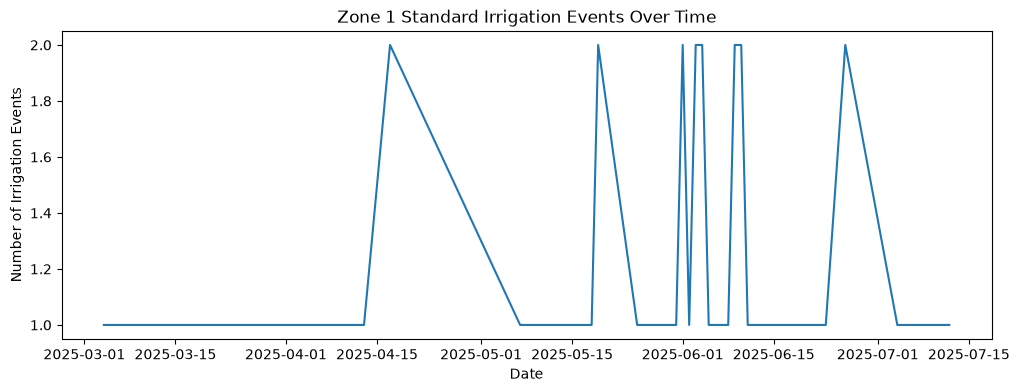

In [24]:
import matplotlib.pyplot as plt
daily_events.plot(figsize=(12,4))

plt.title("Zone 1 Standard Irrigation Events Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Irrigation Events")
plt.show()

In [25]:
df["ts"] = pd.to_datetime(df["ts"])

In [26]:
df["ts"].dtype

dtype('<M8[us]')

In [27]:
df["date"] = df["ts"].dt.date
df[["ts","date"]].head()

,ts,date
0,2025-02-09 00:00:00,2025-02-09
1,2025-02-09 00:10:00,2025-02-09
2,2025-02-09 00:20:00,2025-02-09
3,2025-02-09 00:30:00,2025-02-09
4,2025-02-09 00:40:00,2025-02-09


In [28]:
daily_weather = df.groupby("date").agg({
    "weather_temp": "mean",
    "weather_humidity": "mean",
    "weather_rain": "sum",
    "weather_pressure": "mean",
    "weather_wind_speed": "mean",
    "weather_radiation": "mean"
})

daily_weather.head()

,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation
date,,,,,,
2025-02-09,8.608125,76.898264,0.0,1024.013403,4.921597,72.791667
2025-02-10,7.906563,77.788194,0.0,1022.298090,4.058264,111.958333
2025-02-11,8.020903,87.852431,11.4,1022.079444,4.430590,85.541667
2025-02-12,9.515347,88.647569,2.4,1020.856979,10.780313,18.000000
2025-02-13,10.639757,90.894097,7.2,1016.710208,10.951840,55.416667


In [29]:
daily_weather.shape


(231, 6)

In [30]:
standard_events.head()

,sector,start,end,initial_humidity,final_humidity,stop_reason,type,duration_hours,date
1,1,2025-03-04 16:32:00,2025-03-04 18:00:00,46,46,time_restriction,standard_irrigation,1.47,2025-03-04
2,1,2025-03-10 15:58:00,2025-03-10 16:33:00,44,41,physical_valve_closure,standard_irrigation,0.58,2025-03-10
5,1,2025-04-13 13:14:00,2025-04-13 18:00:00,53,52,time_restriction,standard_irrigation,4.77,2025-04-13
6,1,2025-04-17 09:09:00,2025-04-17 13:15:00,40,22,physical_valve_closure,standard_irrigation,4.10,2025-04-17
7,1,2025-04-17 13:26:00,2025-04-17 18:00:00,22,60,time_restriction,standard_irrigation,4.57,2025-04-17


In [31]:
irrigation_dates = standard_events["start"].dt.date.unique()

In [32]:
daily_weather["irrigation_today"] = (
    daily_weather.index.isin(irrigation_dates)
).astype(int)
# isin = is in?     astype = as type (transfer data type into int)
# if true, 1; if false, 0

In [33]:
daily_weather[daily_weather["irrigation_today"] == 1].head()

,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,irrigation_today
date,,,,,,,
2025-03-04,10.792153,66.140625,0.0,1019.699514,11.505972,155.791667,1
2025-03-10,14.611250,85.584028,0.6,1010.561007,20.646319,64.500000,1
2025-04-13,14.983924,71.028125,3.6,1014.982708,9.573438,67.541667,1
2025-04-17,17.542778,67.805208,25.8,1009.966528,22.721076,16.083333,1
2025-05-07,21.168229,58.571181,0.0,1008.637639,9.127847,219.625000,1


In [34]:
daily_weather["irrigation_next_day"] = (
    daily_weather["irrigation_today"].shift(-1)
)
#.shift(-1) means that the value of the next day will be assigned to the current day. This is because we want to predict whether there will be irrigation tomorrow based on today's weather data.

In [35]:
daily_weather[
    ["irrigation_today", "irrigation_next_day"]
].head(30)

,irrigation_today,irrigation_next_day
date,,
2025-02-09,0,0.0
2025-02-10,0,0.0
2025-02-11,0,0.0
2025-02-12,0,0.0
2025-02-13,0,0.0
2025-02-14,0,0.0
2025-02-15,0,0.0
2025-02-16,0,0.0
2025-02-17,0,0.0


In [36]:
standard_events[["start", "date"]].head(10)

,start,date
1,2025-03-04 16:32:00,2025-03-04
2,2025-03-10 15:58:00,2025-03-10
5,2025-04-13 13:14:00,2025-04-13
6,2025-04-17 09:09:00,2025-04-17
7,2025-04-17 13:26:00,2025-04-17
9,2025-05-07 07:15:00,2025-05-07
14,2025-05-09 06:50:00,2025-05-09
15,2025-05-10 16:14:00,2025-05-10
18,2025-05-12 06:40:00,2025-05-12
20,2025-05-14 06:08:00,2025-05-14


In [37]:
irrigation_dates[:10]

array([datetime.date(2025, 3, 4), datetime.date(2025, 3, 10),
       datetime.date(2025, 4, 13), datetime.date(2025, 4, 17),
       datetime.date(2025, 5, 7), datetime.date(2025, 5, 9),
       datetime.date(2025, 5, 10), datetime.date(2025, 5, 12),
       datetime.date(2025, 5, 14), datetime.date(2025, 5, 15)],
      dtype=object)

In [38]:
print(daily_weather.index[20:30])

print(irrigation_dates[:3])



Index([2025-03-01, 2025-03-02, 2025-03-03, 2025-03-04, 2025-03-05, 2025-03-06,
       2025-03-07, 2025-03-08, 2025-03-09, 2025-03-10],
      dtype='object', name='date')
[datetime.date(2025, 3, 4) datetime.date(2025, 3, 10)
 datetime.date(2025, 4, 13)]


In [39]:
daily_weather.loc[
    daily_weather.index.isin(irrigation_dates),
    ["irrigation_today"]
].head(10)


,irrigation_today
date,
2025-03-04,1
2025-03-10,1
2025-04-13,1
2025-04-17,1
2025-05-07,1
2025-05-09,1
2025-05-10,1
2025-05-12,1
2025-05-14,1


In [40]:
daily_weather["irrigation_next_day"].value_counts()

irrigation_next_day
0.0    193
1.0     37
Name: count, dtype: int64

In [41]:
daily_weather["irrigation_next_day"].value_counts(normalize= True)*100

irrigation_next_day
0.0    83.913043
1.0    16.086957
Name: proportion, dtype: float64

In [42]:
X_low = daily_weather[["weather_temp",
"weather_humidity",
"weather_rain",
"weather_pressure",
"weather_wind_speed",
"weather_radiation"]]
X_low.head(5)

,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation
date,,,,,,
2025-02-09,8.608125,76.898264,0.0,1024.013403,4.921597,72.791667
2025-02-10,7.906563,77.788194,0.0,1022.298090,4.058264,111.958333
2025-02-11,8.020903,87.852431,11.4,1022.079444,4.430590,85.541667
2025-02-12,9.515347,88.647569,2.4,1020.856979,10.780313,18.000000
2025-02-13,10.639757,90.894097,7.2,1016.710208,10.951840,55.416667


In [43]:
daily_weather.head()

,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,irrigation_today,irrigation_next_day
date,,,,,,,,
2025-02-09,8.608125,76.898264,0.0,1024.013403,4.921597,72.791667,0,0.0
2025-02-10,7.906563,77.788194,0.0,1022.298090,4.058264,111.958333,0,0.0
2025-02-11,8.020903,87.852431,11.4,1022.079444,4.430590,85.541667,0,0.0
2025-02-12,9.515347,88.647569,2.4,1020.856979,10.780313,18.000000,0,0.0
2025-02-13,10.639757,90.894097,7.2,1016.710208,10.951840,55.416667,0,0.0


In [44]:
y = daily_weather["irrigation_next_day"]
y.head(5)

date
2025-02-09    0.0
2025-02-10    0.0
2025-02-11    0.0
2025-02-12    0.0
2025-02-13    0.0
Name: irrigation_next_day, dtype: float64

# drop missing values -- .dropna()
# is not nan -- .notna()

日期          X_low          y
--------------------------------
Day 1          X            0
Day 2          X            0
...
Day 230        X            1
Day 231        X           NaN



In [45]:
valid_rows = y.notna()
X_low = X_low.loc[valid_rows]
y = y.loc[valid_rows]

In [46]:
valid_rows = y.notna()
X_low.shape
valid_rows.value_counts()

irrigation_next_day
True    230
Name: count, dtype: int64

In [47]:
print(y.shape)
print(y.isna().sum())
print(valid_rows.value_counts())

(230,)
0
irrigation_next_day
True    230
Name: count, dtype: int64


In [48]:
print(X_low.shape)
print(y.shape)

(230, 6)
(230,)


## Train/ Test Spilt

In [49]:
split_index = int(len(X_low)*0.8)
# split_index = int(len(X_low)*0.8) means that we are splitting the data into 80% training and 20% testing. The split_index is the index where we will split the data.

In [50]:
X_train = X_low.iloc[:184]
X_test  = X_low.iloc[184:]
#.loc   → 根据 label（标签/名字）选
#.iloc  → 根据 integer position（整数位置）选

In [51]:
y_train = y.iloc[:184]
y_test  = y.iloc[184:]

In [52]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(184, 6)
(46, 6)
(184,)
(46,)


### Baseline Model

In [53]:
y_test.value_counts()


irrigation_next_day
0.0    46
Name: count, dtype: int64

In [54]:
## boolean mask (布尔值筛筛选条件）。data[condition]  → 选出满足条件的行
y[y == 1].tail(10)


date
2025-06-15    1.0
2025-06-16    1.0
2025-06-17    1.0
2025-06-21    1.0
2025-06-22    1.0
2025-06-25    1.0
2025-07-03    1.0
2025-07-05    1.0
2025-07-08    1.0
2025-07-11    1.0
Name: irrigation_next_day, dtype: float64

X-low是dataframe 二维数据表
y是 series 一维数据
index 是索引

dataframe 通常是features 作为x series通常是target 作为y


In [55]:
y.index

Index([2025-02-09, 2025-02-10, 2025-02-11, 2025-02-12, 2025-02-13, 2025-02-14,
       2025-02-15, 2025-02-16, 2025-02-17, 2025-02-18,
       ...
       2025-09-17, 2025-09-18, 2025-09-19, 2025-09-20, 2025-09-21, 2025-09-22,
       2025-09-23, 2025-09-24, 2025-09-25, 2025-09-26],
      dtype='object', name='date', length=230)

In [56]:
#把dtype从object转成datetime
y.index = pd.to_datetime(y.index)
y.index

DatetimeIndex(['2025-02-09', '2025-02-10', '2025-02-11', '2025-02-12',
               '2025-02-13', '2025-02-14', '2025-02-15', '2025-02-16',
               '2025-02-17', '2025-02-18',
               ...
               '2025-09-17', '2025-09-18', '2025-09-19', '2025-09-20',
               '2025-09-21', '2025-09-22', '2025-09-23', '2025-09-24',
               '2025-09-25', '2025-09-26'],
              dtype='datetime64[s]', name='date', length=230, freq=None)

In [57]:
#提取所有y==1 的月份
y[y==1].index.month

Index([3, 3, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7],
      dtype='int32', name='date')

In [58]:
#统计1出现次数
y[y==1].index.month.value_counts()

date
6    18
5    11
7     4
3     2
4     2
Name: count, dtype: int64

In [59]:
events_after_july11 = events_zone1[
    events_zone1["start"] > "2025-07-11"
]
events_after_july11.shape
events_after_july11.head()

,sector,start,end,initial_humidity,final_humidity,stop_reason,type,duration_hours
83,1,2025-07-11 06:01:00,2025-07-11 06:16:00,42,39,fertigation_timeout,fertigation,0.25
84,1,2025-07-12 06:01:00,2025-07-12 06:16:00,31,36,fertigation_timeout,fertigation,0.25
85,1,2025-07-12 16:02:00,2025-07-12 16:27:00,41,78,fertigation_timeout,standard_irrigation,0.42
86,1,2025-07-13 09:02:00,2025-07-13 09:17:00,70,64,fertigation_timeout,fertigation,0.25


In [60]:
events_after_july11.tail()

,sector,start,end,initial_humidity,final_humidity,stop_reason,type,duration_hours
83,1,2025-07-11 06:01:00,2025-07-11 06:16:00,42,39,fertigation_timeout,fertigation,0.25
84,1,2025-07-12 06:01:00,2025-07-12 06:16:00,31,36,fertigation_timeout,fertigation,0.25
85,1,2025-07-12 16:02:00,2025-07-12 16:27:00,41,78,fertigation_timeout,standard_irrigation,0.42
86,1,2025-07-13 09:02:00,2025-07-13 09:17:00,70,64,fertigation_timeout,fertigation,0.25


In [61]:
events_zone1["start"].max()

Timestamp('2025-07-13 09:02:00')

In [62]:
df.head()

,ts,outside_temperature,inside_temperature,outside_humidity,inside_humidity,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,soil_temperature_0-7cm,soil_temperature_7-18cm,ec,ph,soil_moisture,irrigation_duration_minutes,liters_total,date
0,2025-02-09 00:00:00,NaN,NaN,NaN,NaN,5.7775,91.0,0.0,1025.785000,5.960000,0.0,7.670000,10.785000,NaN,NaN,NaN,0,0.0,2025-02-09
1,2025-02-09 00:10:00,NaN,NaN,NaN,NaN,5.7275,91.0,0.0,1025.751667,6.093333,0.0,7.603333,10.751667,NaN,NaN,NaN,0,0.0,2025-02-09
2,2025-02-09 00:20:00,NaN,NaN,NaN,NaN,5.6775,91.0,0.0,1025.718333,6.226667,0.0,7.536667,10.718333,NaN,NaN,NaN,0,0.0,2025-02-09
3,2025-02-09 00:30:00,NaN,NaN,NaN,NaN,5.6275,91.0,0.0,1025.685000,6.360000,0.0,7.470000,10.685000,NaN,NaN,NaN,0,0.0,2025-02-09
4,2025-02-09 00:40:00,NaN,NaN,NaN,NaN,5.5775,91.0,0.0,1025.651667,6.493333,0.0,7.403333,10.651667,NaN,NaN,NaN,0,0.0,2025-02-09


In [63]:
df[df["liters_total"]>0].head()
#布尔值筛选  取出 liters_total 这一列。问每一行：“这一行的灌溉水量是否大于 0？” → 得到一串 True / False。

,ts,outside_temperature,inside_temperature,outside_humidity,inside_humidity,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,soil_temperature_0-7cm,soil_temperature_7-18cm,ec,ph,soil_moisture,irrigation_duration_minutes,liters_total,date
1908,2025-02-22 06:00:00,NaN,NaN,NaN,NaN,1.077500,95.000000,0.0,1026.415000,2.400,0.000000,3.185000,7.892500,NaN,NaN,NaN,9,9.9,2025-02-22
1909,2025-02-22 06:10:00,NaN,NaN,NaN,NaN,1.027500,95.000000,0.0,1026.448333,2.400,0.000000,3.151667,7.875833,NaN,NaN,NaN,7,7.7,2025-02-22
3411,2025-03-04 16:30:00,NaN,NaN,NaN,NaN,13.440000,51.875000,0.0,1019.285000,12.455,322.900000,14.312500,11.415000,320.0,6.9,46.0,8,8.8,2025-03-04
3412,2025-03-04 16:40:00,NaN,NaN,NaN,NaN,13.306667,52.708333,0.0,1019.251667,12.355,298.233333,14.229167,11.448333,NaN,6.7,NaN,10,11.0,2025-03-04
3413,2025-03-04 16:50:00,NaN,NaN,NaN,NaN,13.173333,53.541667,0.0,1019.218333,12.255,273.566667,14.145833,11.481667,NaN,6.7,NaN,10,11.0,2025-03-04


In [64]:
df[
    (df["ts"] > "2025-07-13") &
    (df["liters_total"] > 0)
].head(5)

,ts,outside_temperature,inside_temperature,outside_humidity,inside_humidity,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,soil_temperature_0-7cm,soil_temperature_7-18cm,ec,ph,soil_moisture,irrigation_duration_minutes,liters_total,date
22230,2025-07-13 09:00:00,NaN,NaN,NaN,NaN,28.065000,36.250000,0.0,1014.085000,0.282500,378.375,25.8475,27.0,393.0,7.2,70.0,8,8.8,2025-07-13
22231,2025-07-13 09:10:00,NaN,NaN,NaN,NaN,28.431667,34.583333,0.0,1014.051667,0.465833,405.875,26.3975,27.0,386.0,7.0,64.0,8,8.8,2025-07-13


In [65]:
df[
    (df["ts"] > "2025-07-13 09:17:00") &
    (df["liters_total"] > 0)
]

,ts,outside_temperature,inside_temperature,outside_humidity,inside_humidity,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,soil_temperature_0-7cm,soil_temperature_7-18cm,ec,ph,soil_moisture,irrigation_duration_minutes,liters_total,date


In [66]:
df.head()

,ts,outside_temperature,inside_temperature,outside_humidity,inside_humidity,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,soil_temperature_0-7cm,soil_temperature_7-18cm,ec,ph,soil_moisture,irrigation_duration_minutes,liters_total,date
0,2025-02-09 00:00:00,NaN,NaN,NaN,NaN,5.7775,91.0,0.0,1025.785000,5.960000,0.0,7.670000,10.785000,NaN,NaN,NaN,0,0.0,2025-02-09
1,2025-02-09 00:10:00,NaN,NaN,NaN,NaN,5.7275,91.0,0.0,1025.751667,6.093333,0.0,7.603333,10.751667,NaN,NaN,NaN,0,0.0,2025-02-09
2,2025-02-09 00:20:00,NaN,NaN,NaN,NaN,5.6775,91.0,0.0,1025.718333,6.226667,0.0,7.536667,10.718333,NaN,NaN,NaN,0,0.0,2025-02-09
3,2025-02-09 00:30:00,NaN,NaN,NaN,NaN,5.6275,91.0,0.0,1025.685000,6.360000,0.0,7.470000,10.685000,NaN,NaN,NaN,0,0.0,2025-02-09
4,2025-02-09 00:40:00,NaN,NaN,NaN,NaN,5.5775,91.0,0.0,1025.651667,6.493333,0.0,7.403333,10.651667,NaN,NaN,NaN,0,0.0,2025-02-09


In [67]:
#c从datetime中提取出月份
df["month"] = df["ts"].dt.month
df.head()

,ts,outside_temperature,inside_temperature,outside_humidity,inside_humidity,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,soil_temperature_0-7cm,soil_temperature_7-18cm,ec,ph,soil_moisture,irrigation_duration_minutes,liters_total,date,month
0,2025-02-09 00:00:00,NaN,NaN,NaN,NaN,5.7775,91.0,0.0,1025.785000,5.960000,0.0,7.670000,10.785000,NaN,NaN,NaN,0,0.0,2025-02-09,2
1,2025-02-09 00:10:00,NaN,NaN,NaN,NaN,5.7275,91.0,0.0,1025.751667,6.093333,0.0,7.603333,10.751667,NaN,NaN,NaN,0,0.0,2025-02-09,2
2,2025-02-09 00:20:00,NaN,NaN,NaN,NaN,5.6775,91.0,0.0,1025.718333,6.226667,0.0,7.536667,10.718333,NaN,NaN,NaN,0,0.0,2025-02-09,2
3,2025-02-09 00:30:00,NaN,NaN,NaN,NaN,5.6275,91.0,0.0,1025.685000,6.360000,0.0,7.470000,10.685000,NaN,NaN,NaN,0,0.0,2025-02-09,2
4,2025-02-09 00:40:00,NaN,NaN,NaN,NaN,5.5775,91.0,0.0,1025.651667,6.493333,0.0,7.403333,10.651667,NaN,NaN,NaN,0,0.0,2025-02-09,2


In [68]:
df[["ts","liters_total","month"]].head()
#取多个columns，传入一个list，list里放列名。  df[["ts","liters_total","month"]]  → 取出 ts、liters_total、month 三列。

,ts,liters_total,month
0,2025-02-09 00:00:00,0.0,2
1,2025-02-09 00:10:00,0.0,2
2,2025-02-09 00:20:00,0.0,2
3,2025-02-09 00:30:00,0.0,2
4,2025-02-09 00:40:00,0.0,2


In [69]:
df[
    df["liters_total"] > 0
][["ts", "liters_total", "month"]].head()

,ts,liters_total,month
1908,2025-02-22 06:00:00,9.9,2
1909,2025-02-22 06:10:00,7.7,2
3411,2025-03-04 16:30:00,8.8,3
3412,2025-03-04 16:40:00,11.0,3
3413,2025-03-04 16:50:00,11.0,3


知识点summary
df["liters_total"] > 0
        ↓
Boolean Mask 🔴
        ↓
df[mask]
筛选 rows 🔴
        ↓
[["ts", "liters_total", "month"]]
选择多个 columns 🔴
        ↓
.head()
前 5 行 🔴

80/20 chronological split
        ↓
发现 y_test = 46 个 0，完全没有 1
        ↓
为什么后期没有 irrigation？
        ↓
检查 events_zone1
        ↓
Zone 1 最后一条 irrigation event：
2025-07-13 09:02–09:17
        ↓
再检查原始 df 的 liters_total
        ↓
07-13 09:17 后确实没有 liters_total > 0
        ↓
README：
整个农场其他 sectors 的 irrigation 一直存在到 Aug 31
        ↓
所以不是整个 irrigation 数据源坏了
但 README 没解释为什么 Zone 1 停止 irrigation
        ↓
⚠️ 不能擅自说“后面不需要灌溉”，现在开始做EDA：Zone 1 在 7 月前后到底发生了什么变化？后面的 0 能不能作为正常 negative samples（负样本）使用？

In [70]:
#Zone 1 从 February → September，每个月总共用了多少 irrigation water？
#groupby()  → 先按月份分组，再对每组的 liters_total 求和
monthly_water = df.groupby("month")["liters_total"].sum()
monthly_water
#把 df 按照月份 month 分组，在每个月中取出 liters_total，把它们全部加起来，并把结果保存到 monthly_water。

month
2      17.6
3     137.5
4     931.7
5    2299.0
6    3269.2
7     477.4
8       0.0
9       0.0
Name: liters_total, dtype: float64

Irrigation
    ↓
7 月突然下降，8–9 月 = 0
    ↓
Rainfall 有没有明显增加？
    ↓
Soil moisture 有没有明显变化？
    ↓
Sensor availability 有没有发生变化？
    ↓
综合判断后期是不是和前期处于不同 data regime

# EDA 探索性数据分析与数据质量评估

### 因素一：rian fall

In [71]:
monthly_rain = df.groupby("month")["weather_rain"].sum()

In [72]:
daily_weather.head()

,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,irrigation_today,irrigation_next_day
date,,,,,,,,
2025-02-09,8.608125,76.898264,0.0,1024.013403,4.921597,72.791667,0,0.0
2025-02-10,7.906563,77.788194,0.0,1022.298090,4.058264,111.958333,0,0.0
2025-02-11,8.020903,87.852431,11.4,1022.079444,4.430590,85.541667,0,0.0
2025-02-12,9.515347,88.647569,2.4,1020.856979,10.780313,18.000000,0,0.0
2025-02-13,10.639757,90.894097,7.2,1016.710208,10.951840,55.416667,0,0.0


In [73]:
type(daily_weather.index)

pandas.Index

In [74]:
daily_weather.index = pd.to_datetime(daily_weather.index)
#改变daliy_weather的index的数据类型为datetime64[ns]，以便后续进行时间序列分析。
type(daily_weather.index)

pandas.DatetimeIndex

In [75]:
daily_weather["month"] = daily_weather.index.month
## 从 daily_weather 的日期索引中提取月份，并创建新的 month 列。
daily_weather[["weather_rain", "month"]].head()


,weather_rain,month
date,,
2025-02-09,0.0,2
2025-02-10,0.0,2
2025-02-11,11.4,2
2025-02-12,2.4,2
2025-02-13,7.2,2


In [76]:
monthly_rain = daily_weather.groupby("month")["weather_rain"].sum()
monthly_rain
## 查看计算得到的每月总降雨量，观察不同月份 rainfall 的变化。

month
2    258.0
3    544.2
4    333.6
5    274.2
6     10.8
7     13.8
8    250.8
9     73.8
Name: weather_rain, dtype: float64

### 因素二： soil moisture

我们已经查了
Irrigation
    ↓
Rainfall
    ↓
接下来：
Soil Moisture

问题：大约三分之二的数据是 missing values（缺失值）。
研究方向：
① 每个月 soil moisture 平均是多少？
② 每个月到底有多少 soil moisture 数据？


In [77]:
df[["ts", "soil_moisture", "month"]].head()

,ts,soil_moisture,month
0,2025-02-09 00:00:00,NaN,2
1,2025-02-09 00:10:00,NaN,2
2,2025-02-09 00:20:00,NaN,2
3,2025-02-09 00:30:00,NaN,2
4,2025-02-09 00:40:00,NaN,2


In [78]:
df["soil_moisture"].notna().head(10)

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8    False
9    False
Name: soil_moisture, dtype: bool

df
↓
按 month 分组
↓
每个月选择 soil_moisture
↓
检查每个值是不是非 NaN
↓
True = 1，False = 0
↓
计算平均值
↓
× 100
↓
得到百分比


lambda x: x.notna().mean() * 100
理解成：
“对于每个月这一组 soil moisture 数据 x，执行后面的计算。”


In [79]:
monthly_soil_availability = df.groupby("month")["soil_moisture"].apply(
    lambda x: x.notna().mean() * 100
)
monthly_soil_availability
## 查看 February 到 September 每个月 soil_moisture 传感器数据的可用率。

month
2     2.812500
3     3.696237
4     3.888889
5     7.773297
6    24.606481
7    34.879032
8    91.196237
9    84.754056
Name: soil_moisture, dtype: float64

每个月有效 soil_moisture 的 median 是多少？
先看 monthly median（每月中位数）。
soil moisture sensor data 可能存在异常值/outliers（离群值）


In [80]:
monthly_soil_median = df.groupby("month")["soil_moisture"].median()
monthly_soil_median
## 按月份对 soil_moisture 进行分组，并计算每个月土壤湿度的中位数，减少异常值对结果的影响。
#8–9 月 sensor availability 很高，但 soil moisture values 本身可能发生了明显的 distribution shift（分布变化）或异常编码。

month
2    50.0
3    47.0
4    47.0
5    47.0
6    51.0
7    24.0
8    21.0
9   -20.0
Name: soil_moisture, dtype: float64

In [81]:
df[df["month"] == 9][["ts", "soil_moisture"]].head(20)
## 筛选 9 月的数据，并查看前 20 条 soil_moisture 原始记录，检查负值是否普遍存在或可能属于异常数据。

,ts,soil_moisture
29376,2025-09-01 00:00:00,19.0
29377,2025-09-01 00:10:00,19.0
29378,2025-09-01 00:20:00,19.0
29379,2025-09-01 00:30:00,19.0
29380,2025-09-01 00:40:00,19.0
29381,2025-09-01 00:50:00,19.0
29382,2025-09-01 01:00:00,19.0
29383,2025-09-01 01:10:00,19.0
29384,2025-09-01 01:20:00,NaN
29385,2025-09-01 01:30:00,19.0


In [82]:
df[df["month"] == 9]["soil_moisture"].describe()

count    3291.000000
mean      -11.518383
std        16.149300
min       -20.000000
25%       -20.000000
50%       -20.000000
75%       -20.000000
max        20.000000
Name: soil_moisture, dtype: float64

In [83]:
df[
    (df["month"]== 9) &
    (df["soil_moisture"]== -20)
][["ts", "soil_moisture"]].head()
#同时筛选“9 月”和“soil_moisture 等于 -20”的记录，并查看最早出现的几条数据。

,ts,soil_moisture
30107,2025-09-06 01:50:00,-20.0
30108,2025-09-06 02:00:00,-20.0
30109,2025-09-06 02:10:00,-20.0
30110,2025-09-06 02:20:00,-20.0
30111,2025-09-06 02:30:00,-20.0


In [84]:
#9.6 号是变成-20的转折点 看看附近数据到底发生了什么
df.loc[30097:30117,["ts", "soil_moisture"]]

,ts,soil_moisture
30097,2025-09-06 00:10:00,19.0
30098,2025-09-06 00:20:00,19.0
30099,2025-09-06 00:30:00,19.0
30100,2025-09-06 00:40:00,NaN
30101,2025-09-06 00:50:00,19.0
30102,2025-09-06 01:00:00,19.0
30103,2025-09-06 01:10:00,19.0
30104,2025-09-06 01:20:00,19.0
30105,2025-09-06 01:30:00,19.0
30106,2025-09-06 01:40:00,19.0


.loc 语句
.loc[
     要哪些 rows,
     要哪些 columns
]

接下来 找出 9 月 6 日 01:50 以后，soil_moisture 不等于 -20、同时也不是 NaN 的记录。
检查传感器读数之后是否修复

In [85]:
df[
    (df["ts"] > "2025-09-06 01:50:00")&
    (df["soil_moisture"] != -20)&
    (df["soil_moisture"].notna())
][["ts", "soil_moisture"]].head(10)


,ts,soil_moisture


9 月 6 日 01:50 起，soil_moisture 从 19 突然跳变为 -20，之后未再次出现非 -20 的有效读数。
因此，高 sensor availability 不一定代表高 data quality；后续使用 soil_moisture 前需要处理这一异常区间。

## Implications for Modalling Window 

### 探索方向 
到底应该用 February–September 全部 230 天建模，还是限定一个 modelling window（建模时间窗口），以及 Train/Test 到底怎么切，才能让 Test Set 同时包含 0 和 1？

In [86]:
y.head()
# 查看目标变量 y 的前 5 行，重新确认每个日期对应的 next-day irrigation label（0 或 1）。

date
2025-02-09    0.0
2025-02-10    0.0
2025-02-11    0.0
2025-02-12    0.0
2025-02-13    0.0
Name: irrigation_next_day, dtype: float64

In [87]:
y[(y.index.month>= 2) & (y.index.month<= 5)].value_counts()
## 筛选 2 月到 5 月的目标标签 y，并统计训练候选期中 0 和 1 两类标签分别出现多少次。
## Train 部分

irrigation_next_day
0.0    97
1.0    15
Name: count, dtype: int64

In [88]:
y[(y.index.month >= 6) & (y.index.month <= 7)].value_counts()
# Test 部分


irrigation_next_day
0.0    39
1.0    22
Name: count, dtype: int64

Model Evaluation：

模型能识别多少 y=1？
它会不会把很多 y=0 错判成 1？
Precision / Recall / F1 到底怎么样？

接着探究 如果aug-sep的数据不扔掉 那这些数据到底是什么分布？

In [89]:
y[(y.index.month >= 8)& (y.index.month <= 9)].value_counts()

irrigation_next_day
0.0    57
Name: count, dtype: int64

### Train-Test Design

Based on the temporal distribution of irrigation events, the dataset was divided chronologically:

- February–May: Training period
- June–July: Primary testing period
- August–September: Separate late-season evaluation period

The late-season period was not used as the primary test set because it contained no positive standard-irrigation labels.

## Feature Engineering（特征工程）

Feature Engineering（特征工程）是从原始变量中构造更有信息量的新特征。例如，可以将每日降雨量 `weather_rain` 转化为过去 3 天累计降雨量 `rain_3d_sum`，将每日温度和湿度转化为过去 3 天平均值 `temp_3d_mean` 和 `humidity_3d_mean`。这些特征能够帮助模型捕捉天气的短期累积效应，而不仅仅依赖当天的天气状况。但由于本项目的数据量较小（约 230 天，训练期约 112 个样本），不应盲目增加大量特征，否则可能导致 Overfitting（过拟合）。因此，Feature Engineering 应结合 agricultural reasoning（农业逻辑）和 data reasoning（数据逻辑），只构造具有合理解释和潜在预测价值的特征。

#### ·滚动窗口 --- .rolling()
May 9  → May 7 + May 8 + May 9
       → 2 + 10 + 5
       → 17

May 10 → May 8 + May 9 + May 10
       → 10 + 5 + 0
       → 15

May 11 → May 9 + May 10 + May 11
       → 5 + 0 + 3
       → 8

[May 7  May 8  May 9]
        ↓↓↓
       [May 8  May 9  May 10]
               ↓↓↓
              [May 9  May 10  May 11]

In [90]:
daily_weather["rain_3d_sum"] = daily_weather["weather_rain"].rolling(window= 3).sum()
daily_weather[["weather_rain","rain_3d_sum"]].head()
# 对每日降雨量建立 3 天滚动窗口，并计算当天及之前两天的累计降雨量。

,weather_rain,rain_3d_sum
date,,
2025-02-09,0.0,NaN
2025-02-10,0.0,NaN
2025-02-11,11.4,11.4
2025-02-12,2.4,13.8
2025-02-13,7.2,21.0


In [91]:
daily_weather["temp_3d_mean"] = daily_weather["weather_temp"].rolling(window= 3).mean()
daily_weather[["weather_rain","rain_3d_sum","temp_3d_mean"]].head()
# 对每日温度建立 3 天滚动窗口，计算当天及之前两天的平均温度。


,weather_rain,rain_3d_sum,temp_3d_mean
date,,,
2025-02-09,0.0,NaN,NaN
2025-02-10,0.0,NaN,NaN
2025-02-11,11.4,11.4,8.178530
2025-02-12,2.4,13.8,8.480938
2025-02-13,7.2,21.0,9.392002


In [92]:
daily_weather["rain_7d_sum"] = daily_weather["weather_rain"].rolling(window= 7).sum()
daily_weather["humidity_3d_mean"] = daily_weather["weather_humidity"].rolling(window= 3).mean()
daily_weather["radiation_3d_mean"] = daily_weather["weather_radiation"].rolling(window= 3).mean()
daily_weather[["weather_rain","rain_3d_sum","rain_7d_sum","temp_3d_mean","humidity_3d_mean","radiation_3d_mean"]].head(10)

,weather_rain,rain_3d_sum,rain_7d_sum,temp_3d_mean,humidity_3d_mean,radiation_3d_mean
date,,,,,,
2025-02-09,0.00,NaN,NaN,NaN,NaN,NaN
2025-02-10,0.00,NaN,NaN,NaN,NaN,NaN
2025-02-11,11.40,11.40,NaN,8.178530,80.846296,90.097222
2025-02-12,2.40,13.80,NaN,8.480938,84.762731,71.833333
2025-02-13,7.20,21.00,NaN,9.392002,89.131366,52.986111
2025-02-14,4.80,14.40,NaN,10.627766,89.646412,47.569444
2025-02-15,93.53,105.53,119.33,11.426181,89.312384,62.388889
2025-02-16,67.87,166.20,187.20,11.761748,88.021412,52.263889
2025-02-17,14.40,175.80,201.60,11.277373,87.306944,47.888889



7 天滚动特征在数据开始的前 6 天缺少完整历史窗口，因此这些 NaN 并不代表真实值为 0。
为避免人为填充值引入偏差，后续建模时删除缺少完整 rolling features 的样本。

但是不能直接使用.dropna()语法 ，可能会因为其他不相关列的 NaN 把大量本来能用的数据也删掉。data cleaning思想：只根据模型真正使用的变量处理 missing values。

#### 重新构建X_low

In [93]:
X_low = daily_weather[[
    "weather_temp",
    "weather_humidity",
    "weather_rain",
    "weather_pressure",
    "weather_wind_speed",
    "weather_radiation",
    "rain_3d_sum",
    "rain_7d_sum",
    "temp_3d_mean",
    "humidity_3d_mean",
    "radiation_3d_mean"
]]

# 从 daily_weather 中选择 6 个原始天气特征和 5 个工程特征，构建 Low-cost model 的输入数据 X_low。


In [94]:
X_low.head()

,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,rain_3d_sum,rain_7d_sum,temp_3d_mean,humidity_3d_mean,radiation_3d_mean
date,,,,,,,,,,,
2025-02-09,8.608125,76.898264,0.0,1024.013403,4.921597,72.791667,NaN,NaN,NaN,NaN,NaN
2025-02-10,7.906563,77.788194,0.0,1022.298090,4.058264,111.958333,NaN,NaN,NaN,NaN,NaN
2025-02-11,8.020903,87.852431,11.4,1022.079444,4.430590,85.541667,11.4,NaN,8.178530,80.846296,90.097222
2025-02-12,9.515347,88.647569,2.4,1020.856979,10.780313,18.000000,13.8,NaN,8.480938,84.762731,71.833333
2025-02-13,10.639757,90.894097,7.2,1016.710208,10.951840,55.416667,21.0,NaN,9.392002,89.131366,52.986111


In [95]:
X_low.shape

(231, 11)

#### X/y alignment --> Ml ready

In [96]:
X_low.isna().sum()
# 统计 X_low 每个特征中的缺失值数量，检查哪些 engineered features 因 rolling window 产生了 NaN。

weather_temp          0
weather_humidity      0
weather_rain          0
weather_pressure      0
weather_wind_speed    0
weather_radiation     0
rain_3d_sum           2
rain_7d_sum           6
temp_3d_mean          2
humidity_3d_mean      2
radiation_3d_mean     2
dtype: int64

In [97]:
#建立vaild——rows 哪些日期的11个x features全都有数据？
valid_rows = X_low.notna().all(axis= 1)
valid_rows.value_counts()
#axis= 1 横着走 axis= 0 竖着走

True     225
False      6
Name: count, dtype: int64

In [98]:
X_low.index.isin(y.index)
#isin -- is in? X_low的index（日期）在y的index里面吗
valid_rows = valid_rows & X_low.index.isin(y.index)

In [99]:
valid_rows.value_counts()

True     224
False      7
Name: count, dtype: int64

In [100]:
X_low.head()

,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,rain_3d_sum,rain_7d_sum,temp_3d_mean,humidity_3d_mean,radiation_3d_mean
date,,,,,,,,,,,
2025-02-09,8.608125,76.898264,0.0,1024.013403,4.921597,72.791667,NaN,NaN,NaN,NaN,NaN
2025-02-10,7.906563,77.788194,0.0,1022.298090,4.058264,111.958333,NaN,NaN,NaN,NaN,NaN
2025-02-11,8.020903,87.852431,11.4,1022.079444,4.430590,85.541667,11.4,NaN,8.178530,80.846296,90.097222
2025-02-12,9.515347,88.647569,2.4,1020.856979,10.780313,18.000000,13.8,NaN,8.480938,84.762731,71.833333
2025-02-13,10.639757,90.894097,7.2,1016.710208,10.951840,55.416667,21.0,NaN,9.392002,89.131366,52.986111


In [101]:
X_clean = X_low.loc[valid_rows].copy()
y_clean = y.loc[X_clean.index].copy()

#sanity check:
print(X_clean.shape)
print(y_clean.shape)
print(X_clean.index.equals(y_clean.index))
# 检查 X_clean 和 y_clean 的日期索引是否完全一致，确保特征和目标标签一一对应。


(224, 11)
(224,)
True


ML-ready dataset:

X_clean                     y_clean

224 × 11                    224
┌───────────────┐          ┌───┐
│ 11 features   │ ───────→ │ 0 │
│ 11 features   │ ───────→ │ 1 │
│ 11 features   │ ───────→ │ 0 │
│ ...           │          │...│
└───────────────┘          └───┘

#### 构造Train/ Test/ Late-season 数据

In [102]:
train_mask = (X_clean.index.month >= 2) & (X_clean.index.month <= 5)

test_mask = (X_clean.index.month >= 6) & (X_clean.index.month <= 7)

late_mask = (X_clean.index.month >= 8) & (X_clean.index.month <= 9)

## 根据月份创建训练集、主要测试集和晚季评估集的布尔筛选条件，保持数据的时间顺序。

## mask（掩码 / 筛选条件) boolean mask
## # Boolean Mask（布尔掩码）是一组 True/False 条件，用于标记哪些行需要被选择；True 保留，False 不选择。

print(train_mask.sum())
print(test_mask.sum())
print(late_mask.sum())
#sanity check

106
61
57


In [103]:
X_clean.head()

,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,rain_3d_sum,rain_7d_sum,temp_3d_mean,humidity_3d_mean,radiation_3d_mean
date,,,,,,,,,,,
2025-02-15,11.910590,87.645486,93.53,1007.107257,17.028611,62.458333,105.53,119.33,11.426181,89.312384,62.388889
2025-02-16,11.646458,87.021181,67.87,1007.811181,12.696493,25.041667,166.20,187.20,11.761748,88.021412,52.263889
2025-02-17,10.275069,87.254167,14.40,1011.550382,9.002118,56.166667,175.80,201.60,11.277373,87.306944,47.888889
2025-02-18,9.484236,76.623611,0.00,1016.106944,10.281910,78.416667,82.27,190.20,10.468588,83.632986,53.208333
2025-02-19,8.306771,74.962500,1.20,1021.193958,10.300000,91.666667,15.60,189.00,9.355359,79.613426,75.416667


In [104]:
X_train = X_clean.loc[train_mask]
y_train = y_clean.loc[train_mask]

X_test = X_clean.loc[test_mask]
y_test = y_clean.loc[test_mask]

X_late = X_clean.loc[late_mask]
y_late = y_clean.loc[late_mask]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(X_late.shape, y_late.shape)

(106, 11) (106,)
(61, 11) (61,)
(57, 11) (57,)


清洗后的数据：

                 X (features)     y (target)
Training         (106, 11)        (106,)
Primary Test      (61, 11)         (61,)
Late-season       (57, 11)         (57,)

In [105]:
print("Training:")
print(y_train.value_counts())

print("\nPrimary Test:")
print(y_test.value_counts())

print("\nLate-season:")
print(y_late.value_counts())

# 检查训练集、主要测试集和晚季评估集中的 0/1 类别分布，确认每个时间区间的目标标签结构。

Training:
irrigation_next_day
0.0    91
1.0    15
Name: count, dtype: int64

Primary Test:
irrigation_next_day
0.0    39
1.0    22
Name: count, dtype: int64

Late-season:
irrigation_next_day
0.0    57
Name: count, dtype: int64


## Machine Learning

### · Machine Modelling

~~ In this section, machine learning models are trained to predict next-day standard irrigation events using low-cost weather features and engineered historical weather features.

~~ Experimental Setup

- Training period: February–May
- Primary test period: June–July
- Late-season evaluation period: August–September
- Input features: 11 low-cost weather and engineered features
- Target: Next-day standard irrigation event (0/1)


~~ ML 顺序

Machine Learning
       ↓
① Baseline Model
       ↓
② Evaluation Metrics
       ↓
③ Logistic Regression
       ↓
④ 模型训练 fit()
       ↓
⑤ 模型预测 predict()
       ↓
⑥ Precision / Recall / F1
       ↓
⑦ Confusion Matrix
       ↓
⑧ 更强模型 + Comparison

～～ Baseline Model

A baseline model provides a simple reference point for evaluating machine learning models.

Because the irrigation target is imbalanced, accuracy alone can be misleading. A majority-class baseline that always predicts no irrigation (0) can already achieve relatively high accuracy without learning any relationship between weather conditions and irrigation events.

Therefore, subsequent machine learning models should be compared against the baseline using multiple evaluation metrics.

##### · 创建baseline model

In [106]:
import numpy as np
# 导入 NumPy 库，用于创建和处理数值数组。

In [107]:
baseline_pred = np.zeros(len(y_test),dtype = int)
print(baseline_pred[:10])
print(len(baseline_pred))
# 创建与 y_test 长度相同的全 0 预测，作为始终预测“无灌溉”的 majority-class baseline。

[0 0 0 0 0 0 0 0 0 0]
61


##### · Confusion Matrix

- sklearn = scikit-learn，Python 最常用的 Machine Learning library（机器学习库）之一
- metrics = 评价指标模块
- confusion_matrix = 混淆矩阵函数

从 sklearn.metrics 里面，把 confusion_matrix 这个工具拿过来

In [108]:
from sklearn.metrics import confusion_matrix

In [109]:
cm = confusion_matrix(y_test, baseline_pred)
# confusion_matrix(真实答案, 预测答案)

print(cm)

[[39  0]
 [22  0]]


In [110]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# 从 sklearn.metrics 导入 Accuracy、Precision、Recall 和 F1 的计算工具。

In [111]:
baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred, zero_division=0)
# 分母tp+fp = 0，直接定义precision为0
baseline_recall = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)

print("Baseline Accuracy:", baseline_accuracy)
print("Baseline Precision:", baseline_precision)
print("Baseline Recall:", baseline_recall)
print("Baseline F1:", baseline_f1)

Baseline Accuracy: 0.639344262295082
Baseline Precision: 0.0
Baseline Recall: 0.0
Baseline F1: 0.0


· Baseline Results

The majority-class baseline always predicts no irrigation (0).

- Accuracy: 63.9%
- Precision: 0.0%
- Recall: 0.0%
- F1-score: 0.0%

Although the baseline achieves an accuracy of 63.9%, it fails to identify any irrigation events. This demonstrates why accuracy alone is insufficient for evaluating the imbalanced irrigation classification task.

##### · Logistic Regression 逻辑回归

1. Logistic Regression 会从训练数据中学习每个特征的权重，用这些权重组合输入特征进行分类预测。

2. Logistic Regression 先估计 y=1 的概率，再根据分类阈值将概率转换为最终的 0/1 预测。
   11 Features
     ↓
Logistic Regression
     ↓
Probability
     ↓
例如 0.73 (sigmoid)
     ↓
Threshold = 0.5
     ↓
0.73 ≥ 0.5
     ↓
Prediction = 1

3. model.fit(X_train, y_train) : fit -- 使用 X_train 和 y_train 训练模型，让模型从训练样本中学习特征与目标标签之间的关系。

4. model.predict(X_test) : 模型学习完毕 开始考试 只给题目 不给正确答案。
使用训练好的模型对未参与训练的 X_test 进行预测，再与 y_test 的真实标签比较。

（（ ps: logistic regression也通常用于classifictaion， 例如 分成0/1

5. fit() 用训练数据学习规律；predict() 对新数据生成预测；将预测与真实 y 比较后才完成模型评估。


##### logistic regression

In [112]:
from sklearn.linear_model import LogisticRegression
# 从 scikit-learn 的 linear_model 模块中导入 Logistic Regression 模型。

log_model = LogisticRegression(max_iter = 1000)
#max_iter=1000 是允许训练算法最多进行 1000 次 iteration（迭代），帮助它有足够机会完成优化。

log_model.fit(X_train,y_train)

/opt/anaconda3/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

出现问题：ConvergenceWarning:Logistic Regression 尝试学习了最多 1000 次，但在达到 1000 次的时候，优化过程仍然没有完全 convergence（收敛）。

解决方案：scale the data -- feature scaling (standardization)

##### StandardScaler + Logisitic Regression Pipeline

StandardScaler（标准化） → Logistic Regression → Prediction

Pipeline（流水线）将数据预处理和机器学习模型按顺序连接起来，形成统一的训练和预测流程。

In [113]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [114]:
log_pipeline = Pipeline([("scaler",StandardScaler()),
                         ("logistic",LogisticRegression(max_iter=1000))])

log_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logistic', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['weather_temp','weather_humidity','weather_rain',...,'temp_3d_mean', 'humidity_3d_mean','radiation_3d_mean']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


语法：创建Pipeline流水线（）， 创建列表【】，创建tuple（）-- tuple语法：（“步骤的名字”，要执行的工具）

解释：创建 ML Pipeline：先对输入特征进行标准化，再使用 Logistic Regression 进行分类。

Pipeline作用： Pipeline 将 Scaling 和模型连接成统一流程，使训练和预测使用一致的数据处理步骤，并减少手动操作和 Data Leakage 风险。

In [115]:
log_pred = log_pipeline.predict(X_test)
# 使用训练好的 Pipeline 对 X_test 进行处理和预测，得到 61 个 0/1 分类结果。

print(log_pred[:10])
print(len(log_pred))

[0. 0. 0. 0. 1. 1. 1. 1. 1. 1.]
61


In [116]:
print(np.unique(log_pred, return_counts=True))
# 统计 Logistic Regression 分别预测了多少个 0 和 1，初步检查模型的预测行为。

(array([0., 1.]), array([ 4, 57]))


##### Confusion Matrix

In [117]:
cm = confusion_matrix(y_test,log_pred)
print(cm)

[[ 0 39]
 [ 4 18]]


sklearn 固定结构：
[[TN  FP]
 [FN  TP]]

抓到18次irrigation，漏了4次，报错39次


In [118]:
log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)

print("Accuracy:", log_accuracy)
print("Precision:", log_precision)
print("Recall:", log_recall)
print("F1-score:", log_f1)


# 计算 Logistic Regression 的 Accuracy、Precision、Recall 和 F1-score，全面评价模型表现。

Accuracy: 0.29508196721311475
Precision: 0.3157894736842105
Recall: 0.8181818181818182
F1-score: 0.45569620253164556


Logistic Regression Results

The Logistic Regression model achieved approximately:

- Accuracy: 29.5%
- Precision: 31.6%
- Recall: 81.8%
- F1-score: 45.6%

The model detected most true irrigation events, resulting in relatively high recall. However, it predicted irrigation for most test samples and produced many false positives. Therefore, the high recall came at the cost of low precision and poor overall classification performance.


第一个machine learning model

Low-cost Weather Features
          ↓
   StandardScaler
          ↓
 Logistic Regression
          ↓
      Prediction
          ↓
Confusion Matrix + Metrics

### 模型诊断 Model Dagnosis -- 为什么 logistic regerssion 总是预测 irrigation==1？

#### 因素一：天气分布

In [119]:
X_train.describe()

,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,rain_3d_sum,rain_7d_sum,temp_3d_mean,humidity_3d_mean,radiation_3d_mean
count,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000
mean,15.104268,72.270093,13.058491,1012.240227,12.043611,135.792846,39.333962,91.098113,15.024027,72.546760,133.948899
std,4.006664,10.821996,22.705269,6.374963,5.615424,68.169501,52.367430,91.399983,3.864415,9.768560,53.237508
min,6.655660,44.504167,0.000000,997.397396,3.362222,4.125000,0.000000,0.000000,7.065231,47.869560,11.291667
25%,11.933620,66.568142,0.000000,1007.891076,8.118377,89.500000,3.000000,27.750000,11.751105,67.361719,92.000000
50%,15.414531,72.178993,1.347500,1012.096458,11.350330,140.812500,20.400000,57.900000,15.626522,71.011053,133.194444
75%,18.175729,79.585677,14.250000,1015.628542,14.662483,188.989583,39.708750,136.121250,18.144065,81.214931,172.930556
max,22.687014,92.373611,113.300000,1028.031563,28.087917,262.791667,209.705000,398.400000,22.097037,89.312384,238.819444


In [120]:
X_test.describe()

,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,rain_3d_sum,rain_7d_sum,temp_3d_mean,humidity_3d_mean,radiation_3d_mean
count,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000
mean,27.542386,50.698816,0.403279,1010.328963,11.812050,253.161202,1.111475,4.386885,27.456252,50.761796,253.915984
std,2.354159,6.746606,1.586397,3.410682,4.326190,25.325470,2.845704,9.066118,2.342405,5.645252,20.110497
min,21.605590,34.686458,0.000000,1001.747500,5.613472,148.291667,0.000000,0.000000,20.353935,40.756829,191.569444
25%,26.184375,46.814236,0.000000,1008.086389,8.518993,252.083333,0.000000,0.000000,26.428924,46.936458,247.277778
50%,27.118229,50.849653,0.000000,1010.889340,11.181493,262.416667,0.000000,0.000000,27.327431,50.256829,262.430556
75%,29.432917,53.746528,0.000000,1012.984688,14.299618,268.250000,0.000000,3.600000,29.295417,53.360185,265.861111
max,33.043090,72.583333,10.200000,1016.470486,25.389340,277.166667,10.800000,36.000000,31.824861,66.411690,275.333333


In [121]:
X_train.describe().loc["mean"]

weather_temp            15.104268
weather_humidity        72.270093
weather_rain            13.058491
weather_pressure      1012.240227
weather_wind_speed      12.043611
weather_radiation      135.792846
rain_3d_sum             39.333962
rain_7d_sum             91.098113
temp_3d_mean            15.024027
humidity_3d_mean        72.546760
radiation_3d_mean      133.948899
Name: mean, dtype: float64

In [122]:
X_test.describe().loc["mean"]

weather_temp            27.542386
weather_humidity        50.698816
weather_rain             0.403279
weather_pressure      1010.328963
weather_wind_speed      11.812050
weather_radiation      253.161202
rain_3d_sum              1.111475
rain_7d_sum              4.386885
temp_3d_mean            27.456252
humidity_3d_mean        50.761796
radiation_3d_mean      253.915984
Name: mean, dtype: float64

In [123]:

train_mean = X_train.mean()
test_mean = X_test.mean()
train_std = X_train.std()
test_std = X_test.std()

comparison = pd.DataFrame({
    "Train Mean": train_mean,
    "Test Mean":test_mean,
    "Trian Std":train_std,
    "Test Std":test_std
})
comparison

,Train Mean,Test Mean,Trian Std,Test Std
weather_temp,15.104268,27.542386,4.006664,2.354159
weather_humidity,72.270093,50.698816,10.821996,6.746606
weather_rain,13.058491,0.403279,22.705269,1.586397
weather_pressure,1012.240227,1010.328963,6.374963,3.410682
weather_wind_speed,12.043611,11.812050,5.615424,4.326190
weather_radiation,135.792846,253.161202,68.169501,25.325470
rain_3d_sum,39.333962,1.111475,52.367430,2.845704
rain_7d_sum,91.098113,4.386885,91.399983,9.066118
temp_3d_mean,15.024027,27.456252,3.864415,2.342405
humidity_3d_mean,72.546760,50.761796,9.768560,5.645252


##### Train Distribution & Test Distribution

##### weather_temp

In [124]:
X_train.head()
X_test.head()

,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,rain_3d_sum,rain_7d_sum,temp_3d_mean,humidity_3d_mean,radiation_3d_mean
date,,,,,,,,,,,
2025-06-01,21.605590,52.815625,0.0,1016.062569,9.137292,258.666667,0.0,36.0,20.353935,58.724074,258.750000
2025-06-02,23.118646,55.872917,0.0,1016.470486,11.616875,262.291667,0.0,36.0,21.626933,55.680324,261.250000
2025-06-03,23.050069,63.749306,0.0,1016.179514,10.761076,263.708333,0.0,34.8,22.591435,57.479282,261.555556
2025-06-04,22.935451,60.206944,0.0,1015.202604,10.480451,269.625000,0.0,34.8,23.034722,59.943056,265.208333
2025-06-05,24.299306,56.773264,0.0,1013.846111,8.021667,254.375000,0.0,0.0,23.428275,60.243171,262.569444


In [125]:
train_temp = X_train["weather_temp"]
test_temp = X_test["weather_temp"]

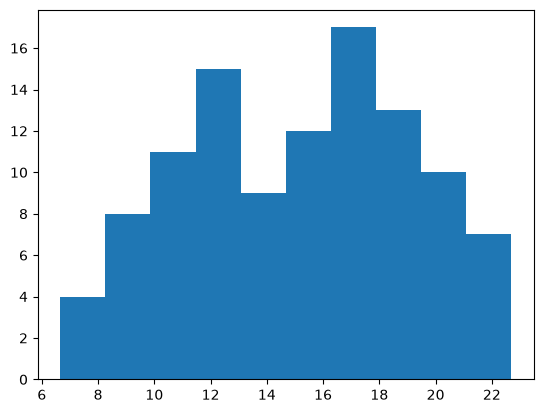

In [126]:
import matplotlib.pyplot as plt
plt.hist(train_temp)
plt.show()

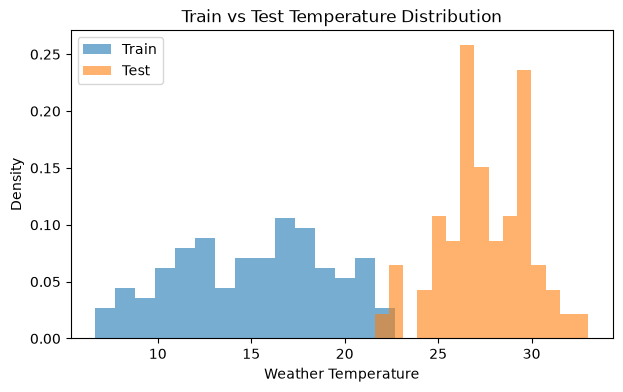

In [127]:
# 比较训练集和测试集的温度分布
plt.figure(figsize=(7, 4))

plt.hist(
    train_temp,
    bins=15,
    alpha=0.6,
    density=True,
    label="Train"
)

plt.hist(
    test_temp,
    bins=15,
    alpha=0.6,
    density=True,
    label="Test"
)

plt.xlabel("Weather Temperature")
plt.ylabel("Density")
plt.title("Train vs Test Temperature Distribution")
plt.legend()

plt.show()

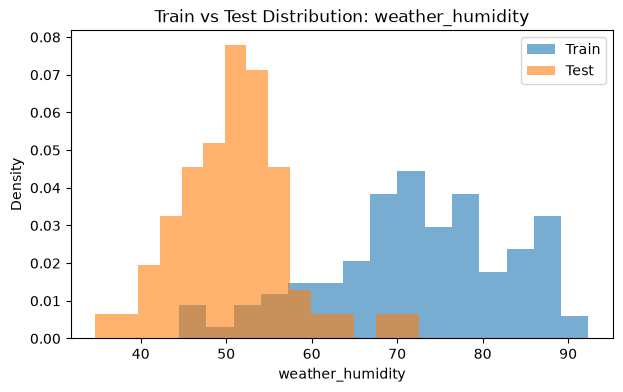

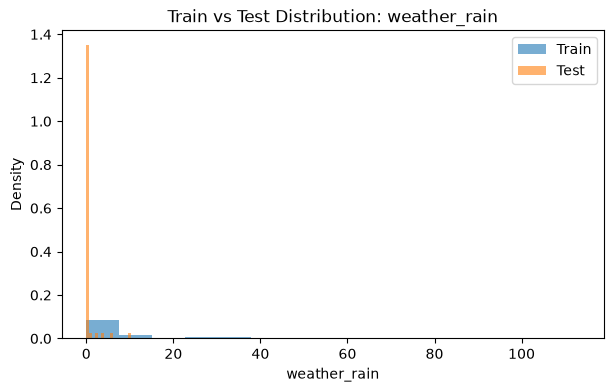

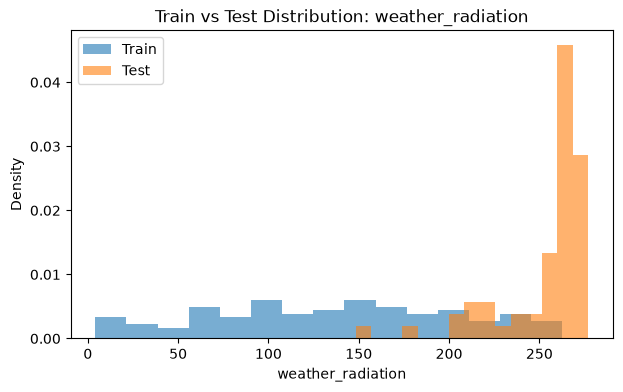

In [128]:
# 选择需要比较的关键天气特征
features_to_plot = [
    "weather_humidity",
    "weather_rain",
    "weather_radiation"
]

# 依次比较每个特征在 Train 和 Test 中的分布
for feature in features_to_plot:

    plt.figure(figsize=(7, 4))

    plt.hist(
        X_train[feature],
        bins=15,
        alpha=0.6,
        density=True,
        label="Train"
    )

    plt.hist(
        X_test[feature],
        bins=15,
        alpha=0.6,
        density=True,
        label="Test"
    )

    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.title(f"Train vs Test Distribution: {feature}")
    plt.legend()

    plt.show()

In [129]:
daily_weather.groupby(
    daily_weather.index.month
)["weather_rain"].agg(["count", "mean", "median", "min", "max", "sum"])

# 按月份检查 rainfall 的统计特征，判断 Train/Test 降雨差异是否来自明显的季节变化或异常数据。

,count,mean,median,min,max,sum
date,,,,,,
2,20,12.900000,2.2675,0.0,93.530,258.0
3,31,17.554839,1.8200,0.0,113.300,544.2
4,30,11.120000,2.7000,0.0,68.400,333.6
5,31,8.845161,0.5900,0.0,85.655,274.2
6,30,0.360000,0.0000,0.0,10.200,10.8
7,31,0.445161,0.0000,0.0,6.000,13.8
8,31,8.090323,0.6000,0.0,168.000,250.8
9,27,2.733333,0.0000,0.0,54.600,73.8


df.groupby(分组变量)["分析变量"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max",
    "sum"
])

## Random Forest

In [ ]:
X_train.head()
X_test.head()
# 查看训练集和测试集，确认 Random Forest 使用的输入特征。

,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,rain_3d_sum,rain_7d_sum,temp_3d_mean,humidity_3d_mean,radiation_3d_mean
date,,,,,,,,,,,
2025-06-01,21.605590,52.815625,0.0,1016.062569,9.137292,258.666667,0.0,36.0,20.353935,58.724074,258.750000
2025-06-02,23.118646,55.872917,0.0,1016.470486,11.616875,262.291667,0.0,36.0,21.626933,55.680324,261.250000
2025-06-03,23.050069,63.749306,0.0,1016.179514,10.761076,263.708333,0.0,34.8,22.591435,57.479282,261.555556
2025-06-04,22.935451,60.206944,0.0,1015.202604,10.480451,269.625000,0.0,34.8,23.034722,59.943056,265.208333
2025-06-05,24.299306,56.773264,0.0,1013.846111,8.021667,254.375000,0.0,0.0,23.428275,60.243171,262.569444


In [131]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [132]:
rf_pred = rf_model.predict(X_test)

print(rf_pred[:10])
print(len(rf_pred))
print(np.unique(rf_pred, return_counts=True))
# 使用训练好的 Random Forest 对测试集进行预测，并检查预测类别的数量分布。


[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
61
(array([0.]), array([61]))


In [133]:
from sklearn.metrics import confusion_matrix

In [134]:
rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[39  0]
 [22  0]]


In [135]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [136]:
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    zero_division=0
)

print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1:", rf_f1)

Accuracy: 0.639344262295082
Precision: 0.0
Recall: 0.0
F1: 0.0


In [137]:
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    zero_division=0
)

print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1:", rf_f1)

# 汇总 Baseline、Logistic Regression 和 Random Forest 的分类指标，比较不同模型的预测表现。

Accuracy: 0.639344262295082
Precision: 0.0
Recall: 0.0
F1: 0.0


In [138]:
# Model comparison | 模型比较
# 🔴 Why: Accuracy 高不代表能识别灌溉；同一 y_test 才能公平比较。
# 🔴 Logic: 使用三个模型已有的预测重新计算指标，不重新训练。
# 🟡 Code meaning: 字典存放模型名和预测；DataFrame 将每个模型的一行结果组成表格。
from sklearn.metrics import balanced_accuracy_score

comparison_predictions = {
    "Baseline": baseline_pred,
    "Logistic Regression": log_pred,
    "Random Forest": rf_pred,
}
comparison_rows = []
for model_name, predictions in comparison_predictions.items():
    assert len(predictions) == len(y_test)
    tn, fp, fn, tp = confusion_matrix(y_test, predictions, labels=[0, 1]).ravel()
    comparison_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_test, predictions),
        "Predicted irrigation": int(np.sum(np.asarray(predictions) == 1)),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
    })
model_comparison = pd.DataFrame(comparison_rows)
# 🟢 只对显示进行四舍五入；model_comparison 保留完整精度。
display(model_comparison.round(4))
print("Output: 检查 RF 是否优于 Baseline，并同时读取 FP（误报）和 FN（漏报）。")

,Model,Accuracy,Precision,Recall,F1,Balanced Accuracy,Predicted irrigation,TN,FP,FN,TP
0,Baseline,0.6393,0.0000,0.0000,0.0000,0.5000,0,39,0,22,0
1,Logistic Regression,0.2951,0.3158,0.8182,0.4557,0.4091,57,0,39,4,18
2,Random Forest,0.6393,0.0000,0.0000,0.0000,0.5000,0,39,0,22,0


Output: 检查 RF 是否优于 Baseline，并同时读取 FP（误报）和 FN（漏报）。


In [139]:
# Class imbalance diagnosis
# 🔴 Why / Logic: 区分类别不平衡与季节变化，保持原时间划分。
# 🟡 Code: value_counts 计数，reindex 补齐类别，mean 求正例比例。
class_rows = []
for split_name, labels in {"Train": y_train, "Test": y_test, "Late-season": y_late}.items():
    assert labels.notna().all() and labels.isin([0, 1]).all()
    counts = labels.value_counts().reindex([0, 1], fill_value=0)
    class_rows.append({"Split": split_name, "N": len(labels), "Class 0": int(counts.loc[0]), "Class 1": int(counts.loc[1]), "Positive rate": float(labels.mean())})
class_distribution = pd.DataFrame(class_rows)
display(class_distribution.round(4))

# 月份按特征日期分组，标签为下一天的灌溉事件。
monthly_class_distribution = y_clean.groupby(y_clean.index.to_period("M")).agg(["count", "sum", "mean"])
monthly_class_distribution.columns = ["N", "Irrigation days", "Positive rate"]
display(monthly_class_distribution.round(4))

# 🟡 balanced 权重 = 训练样本数 / (类别数 * 该类别样本数)，仅用训练标签。
train_class_counts = y_train.value_counts().reindex([0, 1], fill_value=0)
assert (train_class_counts > 0).all()
class_weight_diagnosis = pd.DataFrame({"Train count": train_class_counts, "Balanced weight": len(y_train) / (2 * train_class_counts)})
class_weight_diagnosis.index.name = "Class"
display(class_weight_diagnosis.round(4))
print(f"Train 0:1 ratio = {train_class_counts.loc[0] / train_class_counts.loc[1]:.2f}:1")
print(f"Test - Train positive rate = {(y_test.mean() - y_train.mean()) * 100:.2f} percentage points")
# 🟢 round(4) 仅用于显示。
print("Output: 权重是待检验方案，不保证提升，也不自动修复季节变化。")
print("Late-season 无正例，不能评估灌溉识别能力；需核查停灌或标签记录问题。")

,Split,N,Class 0,Class 1,Positive rate
0,Train,106,91,15,0.1415
1,Test,61,39,22,0.3607
2,Late-season,57,57,0,0.0000


,N,Irrigation days,Positive rate
date,,,
2025-02,14,0.0,0.0000
2025-03,31,2.0,0.0645
2025-04,30,2.0,0.0667
2025-05,31,11.0,0.3548
2025-06,30,18.0,0.6000
2025-07,31,4.0,0.1290
2025-08,31,0.0,0.0000
2025-09,26,0.0,0.0000


,Train count,Balanced weight
Class,,
0,91,0.5824
1,15,3.5333


Train 0:1 ratio = 6.07:1
Test - Train positive rate = 21.91 percentage points
Output: 权重是待检验方案，不保证提升，也不自动修复季节变化。
Late-season 无正例，不能评估灌溉识别能力；需核查停灌或标签记录问题。


In [140]:
# Controlled experiment: class-balanced Random Forest
# 🔴 Why: 检验 RF 的全 0 预测有多少来自类别不平衡。
# 🔴 Logic: 只改变 class_weight；时间划分、特征、树数量和随机种子完全保持不变。
# 🟡 Code meaning: class_weight="balanced" 会让训练时漏掉少数类（灌溉）的代价更高。
rf_balanced_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
rf_balanced_model.fit(X_train, y_train)
rf_balanced_pred = rf_balanced_model.predict(X_test)

rf_balanced_cm = confusion_matrix(y_test, rf_balanced_pred, labels=[0, 1])
rf_balanced_metrics = {
    "Model": "Random Forest (balanced)",
    "Accuracy": accuracy_score(y_test, rf_balanced_pred),
    "Precision": precision_score(y_test, rf_balanced_pred, zero_division=0),
    "Recall": recall_score(y_test, rf_balanced_pred, zero_division=0),
    "F1": f1_score(y_test, rf_balanced_pred, zero_division=0),
    "Balanced Accuracy": balanced_accuracy_score(y_test, rf_balanced_pred),
    "Predicted irrigation": int((rf_balanced_pred == 1).sum()),
}
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(rf_balanced_cm)
display(pd.DataFrame([rf_balanced_metrics]).round(4))
print("Output: 与原 RF 比较 Recall、F1、FP 和 FN；不以 Accuracy 单独决定优劣。")

Confusion matrix [[TN, FP], [FN, TP]]:
[[39  0]
 [22  0]]


,Model,Accuracy,Precision,Recall,F1,Balanced Accuracy,Predicted irrigation
0,Random Forest (balanced),0.6393,0.0,0.0,0.0,0.5,0


Output: 与原 RF 比较 Recall、F1、FP 和 FN；不以 Accuracy 单独决定优劣。


In [141]:
# RLLS hybrid decision model: soil sensor + weather forecast + safety rules
# 🔴 Why: 天气不能直接替代根区含水量；soil_moisture 是最终灌溉确认信号。
# 🔴 Logic: 低于 Zone 1 的启动阈值 40% 才进入灌溉判断；预测降雨可延后；传感器异常时不自动开阀。
# 🟡 Code meaning: 函数把当前传感器值和预测输入转换为可解释的行动与原因。
# 来源：项目已清洗 Zone 1 数据；阈值 40%（启动）/ 60%（停止）。
soil_path = (
    "../Soil Moisture, Irrigation Actuator and Weather Dat/"
    "02_processed_data/preprocessed/dataset_zone_1_preprocessed.csv"
)
rlls_sensor = pd.read_csv(soil_path, parse_dates=["ts"])[["ts", "soil_moisture"]].dropna()
assert rlls_sensor["soil_moisture"].between(0, 100).all()

START_MOISTURE = 40.0  # irrigate below this value
STOP_MOISTURE = 60.0   # do not irrigate at or above this value
RAIN_HOLD_MM = 5.0    # configurable forecast threshold

def rlls_decide(soil_moisture, forecast_rain_mm, forecast_max_temp_c):
    if not 0 <= soil_moisture <= 100:
        return {"Action": "Sensor check", "Reason": "Invalid soil-moisture reading; valve remains closed."}
    if soil_moisture >= STOP_MOISTURE:
        return {"Action": "Wait", "Reason": f"Soil moisture {soil_moisture:.1f}% is at/above the {STOP_MOISTURE:.0f}% stop threshold."}
    if soil_moisture < START_MOISTURE and forecast_rain_mm >= RAIN_HOLD_MM:
        return {"Action": "Wait and recheck", "Reason": f"Soil is dry ({soil_moisture:.1f}%), but {forecast_rain_mm:.1f} mm rain is forecast."}
    if soil_moisture < START_MOISTURE:
        return {"Action": "Irrigate", "Reason": f"Soil is dry ({soil_moisture:.1f}%) and forecast rain is only {forecast_rain_mm:.1f} mm."}
    return {"Action": "Monitor", "Reason": f"Soil moisture {soil_moisture:.1f}% is within the 40–60% operating band."}

# 用真实清洗后传感器读数演示四种决策情境；weather forecast 是演示输入，不是历史预测回测。
q = rlls_sensor["soil_moisture"].quantile([0.10, 0.50, 0.90])
scenarios = pd.DataFrame([
    {"Scenario": "Dry soil + no rain", "soil_moisture": q.loc[0.10], "forecast_rain_mm": 0.0, "forecast_max_temp_c": 31.0},
    {"Scenario": "Dry soil + rain forecast", "soil_moisture": q.loc[0.10], "forecast_rain_mm": 8.0, "forecast_max_temp_c": 27.0},
    {"Scenario": "Operating band", "soil_moisture": q.loc[0.50], "forecast_rain_mm": 0.0, "forecast_max_temp_c": 30.0},
    {"Scenario": "Wet soil", "soil_moisture": max(q.loc[0.90], STOP_MOISTURE), "forecast_rain_mm": 0.0, "forecast_max_temp_c": 30.0},
])
decisions = scenarios.apply(lambda row: rlls_decide(row.soil_moisture, row.forecast_rain_mm, row.forecast_max_temp_c), axis=1, result_type="expand")
rlls_demo = pd.concat([scenarios, decisions], axis=1)
display(rlls_demo.round(2))
print(f"Loaded {len(rlls_sensor):,} cleaned soil-moisture readings for Zone 1.")
print("Output: RLLS acts only after soil confirmation; it does not use the failed weather-only classifier as an automatic valve command.")

,Scenario,soil_moisture,forecast_rain_mm,forecast_max_temp_c,Action,Reason
0,Dry soil + no rain,19.0,0.0,31.0,Irrigate,Soil is dry (19.0%) and forecast rain is only ...
1,Dry soil + rain forecast,19.0,8.0,27.0,Wait and recheck,"Soil is dry (19.0%), but 8.0 mm rain is forecast."
2,Operating band,23.0,0.0,30.0,Irrigate,Soil is dry (23.0%) and forecast rain is only ...
3,Wet soil,60.0,0.0,30.0,Wait,Soil moisture 60.0% is at/above the 60% stop t...


Loaded 9,531 cleaned soil-moisture readings for Zone 1.
Output: RLLS acts only after soil confirmation; it does not use the failed weather-only classifier as an automatic valve command.


In [142]:
# RLLS threshold validation
# 🔴 Why: 阈值逻辑必须覆盖四种不同的可解释状态。
# 这里的土壤湿度数值是控制器测试输入；并非历史天气回测。
threshold_scenarios = pd.DataFrame([
    {"Scenario": "Dry soil, no rain", "soil_moisture": 19.0, "forecast_rain_mm": 0.0, "forecast_max_temp_c": 31.0},
    {"Scenario": "Dry soil, rain forecast", "soil_moisture": 19.0, "forecast_rain_mm": 8.0, "forecast_max_temp_c": 27.0},
    {"Scenario": "Operating band (50%)", "soil_moisture": 50.0, "forecast_rain_mm": 0.0, "forecast_max_temp_c": 30.0},
    {"Scenario": "At stop threshold (60%)", "soil_moisture": 60.0, "forecast_rain_mm": 0.0, "forecast_max_temp_c": 30.0},
])
threshold_decisions = threshold_scenarios.apply(
    lambda row: rlls_decide(row.soil_moisture, row.forecast_rain_mm, row.forecast_max_temp_c),
    axis=1, result_type="expand"
)
rlls_threshold_test = pd.concat([threshold_scenarios, threshold_decisions], axis=1)
expected_actions = ["Irrigate", "Wait and recheck", "Monitor", "Wait"]
assert rlls_threshold_test["Action"].tolist() == expected_actions
display(rlls_threshold_test)
print("Output: 四种动作均通过阈值验证；实际部署前需用本地农艺经验校准阈值与灌溉时长。")

,Scenario,soil_moisture,forecast_rain_mm,forecast_max_temp_c,Action,Reason
0,"Dry soil, no rain",19.0,0.0,31.0,Irrigate,Soil is dry (19.0%) and forecast rain is only ...
1,"Dry soil, rain forecast",19.0,8.0,27.0,Wait and recheck,"Soil is dry (19.0%), but 8.0 mm rain is forecast."
2,Operating band (50%),50.0,0.0,30.0,Monitor,Soil moisture 50.0% is within the 40–60% opera...
3,At stop threshold (60%),60.0,0.0,30.0,Wait,Soil moisture 60.0% is at/above the 60% stop t...


Output: 四种动作均通过阈值验证；实际部署前需用本地农艺经验校准阈值与灌溉时长。


,Action,Days
0,Monitor,97
1,Irrigate,82


Action,Irrigate,Monitor,Wait,Wait and recheck
month,,,,
2025-02,0,1,0,0
2025-03,4,25,0,0
2025-04,9,18,0,0
2025-05,7,22,0,0
2025-06,8,22,0,0
2025-07,19,9,0,0
2025-08,31,0,0,0
2025-09,4,0,0,0


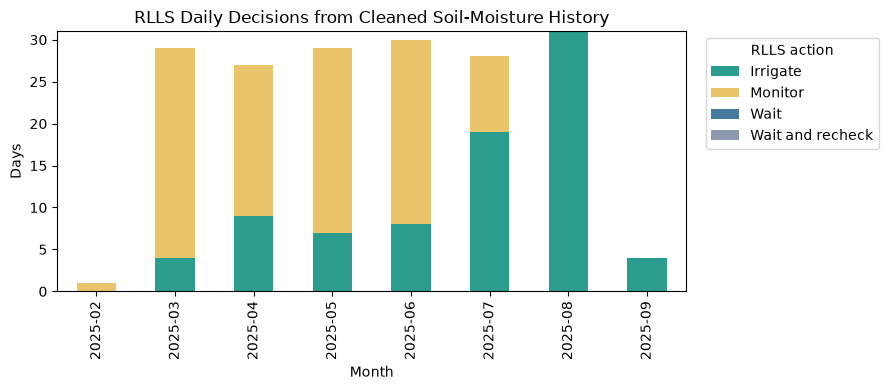

Output: 179 historical days were replayed from cleaned sensor data.
This is a controller-behaviour replay, not a forecast-accuracy score.


In [143]:
# RLLS historical replay: sensor-confirmed baseline
# 🔴 Why: 查看控制器在真实历史土壤读数上会采取什么行动。
# 🔴 Logic: 每日取最后一条可用的清洗读数；历史数据没有未来天气预报，因此此回放只验证传感器安全层。
# 🟡 Code meaning: resample("D") 将 10 分钟读数变成逐日决策输入；不把未来降雨当成预测输入。
rlls_daily_replay = (
    rlls_sensor.set_index("ts")["soil_moisture"]
    .resample("D").last().dropna()
    .to_frame(name="soil_moisture")
)
rlls_daily_replay["forecast_rain_mm"] = 0.0  # no historical forecast available
rlls_daily_replay["forecast_max_temp_c"] = np.nan
rlls_daily_replay[["Action", "Reason"]] = rlls_daily_replay.apply(
    lambda row: pd.Series(rlls_decide(row.soil_moisture, row.forecast_rain_mm, row.forecast_max_temp_c)),
    axis=1
)
rlls_daily_replay["month"] = rlls_daily_replay.index.to_period("M").astype(str)
action_summary = rlls_daily_replay["Action"].value_counts().rename_axis("Action").reset_index(name="Days")
display(action_summary)

monthly_actions = (
    rlls_daily_replay.groupby(["month", "Action"]).size()
    .unstack(fill_value=0)
    .reindex(columns=["Irrigate", "Monitor", "Wait", "Wait and recheck"], fill_value=0)
)
display(monthly_actions)
monthly_actions.plot(kind="bar", stacked=True, figsize=(9, 4), color=["#2a9d8f", "#e9c46a", "#457b9d", "#8d99ae"])
plt.title("RLLS Daily Decisions from Cleaned Soil-Moisture History")
plt.xlabel("Month")
plt.ylabel("Days")
plt.legend(title="RLLS action", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
print(f"Output: {len(rlls_daily_replay)} historical days were replayed from cleaned sensor data.")
print("This is a controller-behaviour replay, not a forecast-accuracy score.")

In [145]:
# RLLS Experiment 1: How much sensing information is necessary?
# 🔴 Why: 在相同预测任务、相同时间切分、相同模型下，只改变输入信息量。
# 🔴 Target: predict whether Zone-specific soil moisture will fall below its start threshold in the next horizon.
# ⚠️ target_point_24h uses 144 cleaned steps; treat this as a first benchmark, not an exact-clock 24h claim.
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score, confusion_matrix

processed_dir = Path("../Soil Moisture, Irrigation Actuator and Weather Dat/02_processed_data/preprocessed")
zone_thresholds = {1: 40, 2: 40, 3: 60, 4: 80, 5: 50}
frames = []
for zone, threshold in zone_thresholds.items():
    zone_data = pd.read_csv(processed_dir / f"dataset_zone_{zone}_preprocessed.csv", parse_dates=["ts"])
    zone_data["zone"] = zone
    zone_data["future_dry"] = (zone_data["target_point_24h"] < threshold).astype(int)
    # Impossible EC/pH values are treated as unavailable, then imputed inside each training pipeline.
    zone_data.loc[~zone_data["ec"].between(0, 1000), "ec"] = np.nan
    zone_data.loc[~zone_data["ph"].between(3, 9), "ph"] = np.nan
    frames.append(zone_data)
sensing_data = pd.concat(frames, ignore_index=True)
train_sensing = sensing_data[sensing_data["ts"].between("2025-03-01", "2025-05-31 23:59:59")].copy()
test_sensing = sensing_data[sensing_data["ts"].between("2025-06-01", "2025-07-31 23:59:59")].copy()

weather_features = ["weather_temp", "weather_humidity", "weather_rain", "weather_pressure", "weather_wind_speed", "weather_radiation"]
sensing_configs = {
    "C0 Weather-only": weather_features,
    "C1 Soil-only": ["soil_moisture"],
    "C2 Low-cost hybrid": ["soil_moisture"] + weather_features,
    "C3 Sensor-rich": ["soil_moisture"] + weather_features + ["soil_temperature_0-7cm", "soil_temperature_7-18cm", "ec", "ph", "water_vol_past_4h"],
}
results = []
for configuration, features in sensing_configs.items():
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("rf", RandomForestClassifier(n_estimators=200, class_weight="balanced", min_samples_leaf=5, random_state=42, n_jobs=-1)),
    ])
    model.fit(train_sensing[features], train_sensing["future_dry"])
    prediction = model.predict(test_sensing[features])
    tn, fp, fn, tp = confusion_matrix(test_sensing["future_dry"], prediction, labels=[0, 1]).ravel()
    results.append({
        "Configuration": configuration, "Features": len(features),
        "Accuracy": accuracy_score(test_sensing["future_dry"], prediction),
        "Precision": precision_score(test_sensing["future_dry"], prediction, zero_division=0),
        "Recall": recall_score(test_sensing["future_dry"], prediction, zero_division=0),
        "F1": f1_score(test_sensing["future_dry"], prediction, zero_division=0),
        "Balanced accuracy": balanced_accuracy_score(test_sensing["future_dry"], prediction),
        "FP": fp, "FN": fn, "TP": tp, "TN": tn,
    })
sensing_comparison = pd.DataFrame(results)
display(sensing_comparison.round(4))
print(f"Train samples: {len(train_sensing):,}; test samples: {len(test_sensing):,}")
print(f"Future-dry rate — train: {train_sensing.future_dry.mean():.1%}; test: {test_sensing.future_dry.mean():.1%}")
print("Output: this is the first temporal sensing-ablation benchmark. Next: raw-data availability and controlled missingness robustness.")

,Configuration,Features,Accuracy,Precision,Recall,F1,Balanced accuracy,FP,FN,TP,TN
0,C0 Weather-only,6,0.5848,0.3226,0.1926,0.2412,0.4909,1604,3203,764,6007
1,C1 Soil-only,1,0.5890,0.4225,0.5437,0.4755,0.5782,2948,1810,2157,4663
2,C2 Low-cost hybrid,7,0.5968,0.3248,0.1639,0.2178,0.4932,1351,3317,650,6260
3,C3 Sensor-rich,12,0.6276,0.3969,0.1674,0.2355,0.5174,1009,3303,664,6602


Train samples: 8,914; test samples: 11,578
Future-dry rate — train: 12.5%; test: 34.3%
Output: this is the first temporal sensing-ablation benchmark. Next: raw-data availability and controlled missingness robustness.


In [146]:
# RLLS Experiment 2: controlled sensor-availability stress test
# 🔴 Why: Raw field data show sensors are intermittently available. Test accuracy is not enough if a system cannot see its sensors.
# 🟡 Logic: Randomly retain readings at observed raw availability rates; this is an MCAR stress test, not a claim that real outages are random.
sensor_availability = {"soil_moisture": 0.33, "ec": 0.41, "ph": 0.83}
rng = np.random.default_rng(42)
stress_results = []
for configuration in ["C1 Soil-only", "C2 Low-cost hybrid", "C3 Sensor-rich"]:
    features = sensing_configs[configuration]
    X_train_stress = train_sensing[features].copy()
    X_test_stress = test_sensing[features].copy()
    for feature in features:
        if feature in sensor_availability:
            X_train_stress.loc[rng.random(len(X_train_stress)) > sensor_availability[feature], feature] = np.nan
            X_test_stress.loc[rng.random(len(X_test_stress)) > sensor_availability[feature], feature] = np.nan
    stress_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("rf", RandomForestClassifier(n_estimators=200, class_weight="balanced", min_samples_leaf=5, random_state=42, n_jobs=-1)),
    ])
    stress_model.fit(X_train_stress, train_sensing["future_dry"])
    stress_pred = stress_model.predict(X_test_stress)
    stress_results.append({
        "Configuration": configuration,
        "Precision": precision_score(test_sensing["future_dry"], stress_pred, zero_division=0),
        "Recall": recall_score(test_sensing["future_dry"], stress_pred, zero_division=0),
        "F1": f1_score(test_sensing["future_dry"], stress_pred, zero_division=0),
        "Balanced accuracy": balanced_accuracy_score(test_sensing["future_dry"], stress_pred),
    })
missingness_stress = pd.DataFrame(stress_results)
display(missingness_stress.round(4))
print("Assumed availability: soil moisture 33%, EC 41%, pH 83%; weather remains available.")
print("Output: compare this table with Experiment 1 to separate clean-data performance from availability robustness.")

,Configuration,Precision,Recall,F1,Balanced accuracy
0,C1 Soil-only,0.3491,0.8107,0.4880,0.5114
1,C2 Low-cost hybrid,0.3289,0.2206,0.2641,0.4930
2,C3 Sensor-rich,0.2177,0.0708,0.1069,0.4691


Assumed availability: soil moisture 33%, EC 41%, pH 83%; weather remains available.
Output: compare this table with Experiment 1 to separate clean-data performance from availability robustness.


,Configuration,Additional missingness,Precision,Recall,F1,Balanced accuracy
0,C1 Soil-only,0.0,0.4255,0.5447,0.4778,0.5807
1,C2 Low-cost hybrid,0.0,0.2947,0.1293,0.1797,0.4840
2,C3 Sensor-rich,0.0,0.3556,0.1760,0.2354,0.5049
3,C1 Soil-only,0.1,0.3382,0.3393,0.3387,0.4966
4,C2 Low-cost hybrid,0.1,0.2953,0.1664,0.2128,0.4797
5,C3 Sensor-rich,0.1,0.3021,0.1699,0.2175,0.4827
6,C1 Soil-only,0.3,0.3736,0.6241,0.4674,0.5393
7,C2 Low-cost hybrid,0.3,0.3171,0.2186,0.2588,0.4866
8,C3 Sensor-rich,0.3,0.2453,0.1250,0.1656,0.4623
9,C1 Soil-only,0.5,0.1785,0.0794,0.1099,0.4444


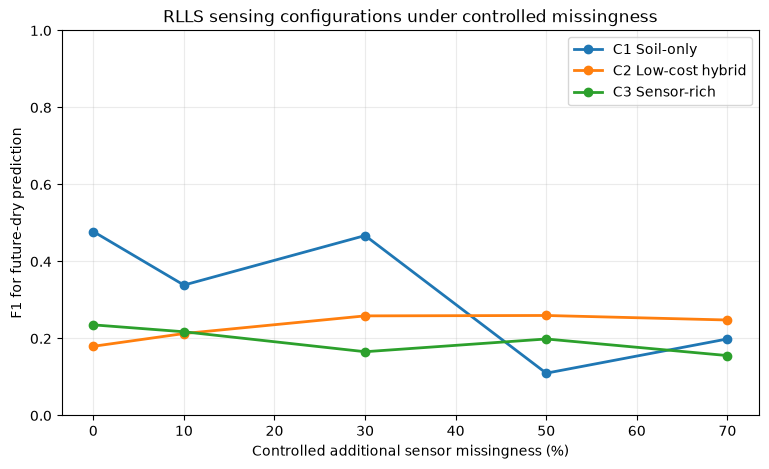

Output: controlled sensitivity for this case-study split; not a universal sensor-reliability claim.


,Configuration,Additional missingness,Precision,Recall,F1,Balanced accuracy
0,C1 Soil-only,0.0,0.4255,0.5447,0.4778,0.5807
1,C2 Low-cost hybrid,0.0,0.2947,0.1293,0.1797,0.4840
2,C3 Sensor-rich,0.0,0.3556,0.1760,0.2354,0.5049
3,C1 Soil-only,0.1,0.3382,0.3393,0.3387,0.4966
4,C2 Low-cost hybrid,0.1,0.2953,0.1664,0.2128,0.4797
5,C3 Sensor-rich,0.1,0.3021,0.1699,0.2175,0.4827
6,C1 Soil-only,0.3,0.3736,0.6241,0.4674,0.5393
7,C2 Low-cost hybrid,0.3,0.3171,0.2186,0.2588,0.4866
8,C3 Sensor-rich,0.3,0.2453,0.1250,0.1656,0.4623
9,C1 Soil-only,0.5,0.1785,0.0794,0.1099,0.4444


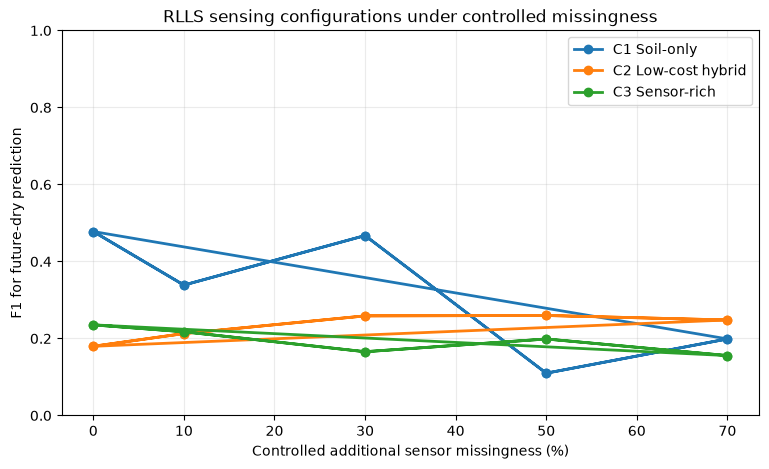

Output: controlled sensitivity for this case-study split; not a universal sensor-reliability claim.


In [150]:
# RLLS Experiment 3: standardized missingness sensitivity curve
# 🔴 Why: test each sensing configuration under identical information loss.
# 🔴 Scope: controlled random masking (MCAR), not a real-world sensor-quality claim.
missing_rates = [0.0, 0.1, 0.3, 0.5, 0.7]
sensor_features = {"soil_moisture", "ec", "ph", "soil_temperature_0-7cm", "soil_temperature_7-18cm"}
curve_rows = []
# RLLS Experiment 3: standardized missingness sensitivity curve
# 🔴 Why: test each sensing configuration under identical information loss.
# 🔴 Scope: controlled random masking (MCAR), not a real-world sensor-quality claim.
missing_rates = [0.0, 0.1, 0.3, 0.5, 0.7]
sensor_features = {"soil_moisture", "ec", "ph", "soil_temperature_0-7cm", "soil_temperature_7-18cm"}
curve_rows = []

for missing_rate in missing_rates:
    for configuration in ["C1 Soil-only", "C2 Low-cost hybrid", "C3 Sensor-rich"]:
        features = sensing_configs[configuration]
        X_train_curve = train_sensing[features].copy()
        X_test_curve = test_sensing[features].copy()
        rng = np.random.default_rng(100 + int(missing_rate * 100))
        for feature in set(features) & sensor_features:
            X_train_curve.loc[rng.random(len(X_train_curve)) < missing_rate, feature] = np.nan
            X_test_curve.loc[rng.random(len(X_test_curve)) < missing_rate, feature] = np.nan
        curve_model = Pipeline([("imputer", SimpleImputer(strategy="median", add_indicator=True)), ("model", RandomForestClassifier(n_estimators=100, class_weight="balanced", min_samples_leaf=5, random_state=42, n_jobs=-1))])
        curve_model.fit(X_train_curve, train_sensing["future_dry"])
        curve_pred = curve_model.predict(X_test_curve)
        curve_rows.append({"Configuration": configuration, "Additional missingness": missing_rate, "Precision": precision_score(test_sensing["future_dry"], curve_pred, zero_division=0), "Recall": recall_score(test_sensing["future_dry"], curve_pred, zero_division=0), "F1": f1_score(test_sensing["future_dry"], curve_pred, zero_division=0), "Balanced accuracy": balanced_accuracy_score(test_sensing["future_dry"], curve_pred)})

missingness_curve = pd.DataFrame(curve_rows)
display(missingness_curve.round(4))
plt.figure(figsize=(9, 5))
for configuration, group in missingness_curve.groupby("Configuration"):
    plt.plot(group["Additional missingness"] * 100, group["F1"], marker="o", linewidth=2, label=configuration)
plt.xlabel("Controlled additional sensor missingness (%)")
plt.ylabel("F1 for future-dry prediction")
plt.title("RLLS sensing configurations under controlled missingness")
plt.ylim(0, 1)
plt.grid(alpha=0.25)
plt.legend()
plt.show()
print("Output: controlled sensitivity for this case-study split; not a universal sensor-reliability claim.")
for missing_rate in missing_rates:
    for configuration in ["C1 Soil-only", "C2 Low-cost hybrid", "C3 Sensor-rich"]:
        features = sensing_configs[configuration]
        X_train_curve = train_sensing[features].copy()
        X_test_curve = test_sensing[features].copy()
        rng = np.random.default_rng(100 + int(missing_rate * 100))
        for feature in set(features) & sensor_features:
            X_train_curve.loc[rng.random(len(X_train_curve)) < missing_rate, feature] = np.nan
            X_test_curve.loc[rng.random(len(X_test_curve)) < missing_rate, feature] = np.nan
        curve_model = Pipeline([("imputer", SimpleImputer(strategy="median", add_indicator=True)), ("model", RandomForestClassifier(n_estimators=100, class_weight="balanced", min_samples_leaf=5, random_state=42, n_jobs=-1))])
        curve_model.fit(X_train_curve, y_train_sensing)
        curve_pred = curve_model.predict(X_test_curve)
        curve_rows.append({"Configuration": configuration, "Additional missingness": missing_rate, "Precision": precision_score(y_test_sensing, curve_pred, zero_division=0), "Recall": recall_score(y_test_sensing, curve_pred, zero_division=0), "F1": f1_score(y_test_sensing, curve_pred, zero_division=0), "Balanced accuracy": balanced_accuracy_score(y_test_sensing, curve_pred)})

missingness_curve = pd.DataFrame(curve_rows)
display(missingness_curve.round(4))
plt.figure(figsize=(9, 5))
for configuration, group in missingness_curve.groupby("Configuration"):
    plt.plot(group["Additional missingness"] * 100, group["F1"], marker="o", linewidth=2, label=configuration)
plt.xlabel("Controlled additional sensor missingness (%)")
plt.ylabel("F1 for future-dry prediction")
plt.title("RLLS sensing configurations under controlled missingness")
plt.ylim(0, 1)
plt.grid(alpha=0.25)
plt.legend()
plt.show()
print("Output: controlled sensitivity for this case-study split; not a universal sensor-reliability claim.")

In [149]:
y_train_sensing = train_sensing["future_dry"]
y_test_sensing = test_sensing["future_dry"]
print("Experiment 3 variables ready.")

Experiment 3 variables ready.


## Experiment Audit

问题：class imbalance 
解决方案：让模型训练时更加重视数量少的irrigation_next_day = 1

controlled experiment:
变量：class weight
不变：X_train 一样
 y_train 一样
 X_test 一样
 y_test 一样
 11 个 features 一样
 时间切分一样
 Logistic Regression 一样
 Evaluation 一样

# Research Technical Core v1 — 审计后独立重跑入口

**从本节开始，在新内核中依次运行即可；不依赖前面 213 个单元格的变量。** 也可运行同目录的 `research_core_v1.ipynb`（Run All）或项目 `src/research_core_v1.py`。

之前完成：Zone 1 日级天气与次日灌溉事件建模、LR/RF/类别平衡探索、5 个 zone 的 sensing 原型及缺失曲线。现在方向：固定预测问题、样本、时间切分、模型与评价，仅改变信息配置或缺失条件，形成可复跑的研究证据。

**两个任务不能混淆**：早期 `irrigation_next_day` 是历史操作事件；本节 `future_dry` 是未来土壤读数低于各 zone 的历史启动阈值。它不是未来 24 小时内“曾经变干”，也不是“不灌溉就会变干”的因果标签。历史期间实际灌溉仍会改变结果。

旧单元格与输出完整保留；旧代码有顺序依赖，不推荐全本 Run All。新核心使用独立命名空间，输出目录每次可重建。**本节 freeze 的是离线研究协议，不是部署合格证明。**

In [1]:
# 初始化独立研究环境，固定特征、参数和输出目录。
from pathlib import Path
import os, json, hashlib, platform, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
    balanced_accuracy_score, confusion_matrix, average_precision_score,
    precision_recall_curve, auc)
from IPython.display import display

# 可以用环境变量切换项目位置；默认从当前目录向上查找。
def v1_find_root():
    if os.environ.get('IRRIGATION_PROJECT_ROOT'):
        return Path(os.environ['IRRIGATION_PROJECT_ROOT']).resolve()
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p/'data/merged/dataset_zone_1.csv').exists(): return p
    p = Path('/Users/kaylasun/Downloads/low-cost-irrigation')
    if (p/'data/merged/dataset_zone_1.csv').exists(): return p
    raise FileNotFoundError('请设置 IRRIGATION_PROJECT_ROOT 为 low-cost-irrigation 文件夹')
v1_root = v1_find_root()
v1_out = Path(os.environ.get('RESEARCH_OUTPUT_DIR', str(v1_root/'outputs/research_core_v1')))
v1_out.mkdir(parents=True, exist_ok=True)
v1_started = time.time()
v1_weather = ['weather_temp','weather_humidity','weather_rain','weather_pressure','weather_wind_speed','weather_radiation']
v1_configs = {
    'C1 Soil-only': ['soil_moisture'],
    'C2 Low-cost hybrid': ['soil_moisture'] + v1_weather,
    'C3 Sensor-rich': ['soil_moisture'] + v1_weather + ['soil_temperature_0-7cm','soil_temperature_7-18cm','ec','ph','water_vol_past_4h']}
v1_all = v1_configs['C3 Sensor-rich']
v1_thresholds = {1:40,2:40,3:60,4:80,5:50}
v1_rf_params = dict(n_estimators=200, class_weight='balanced', min_samples_leaf=5, random_state=42, n_jobs=2)
v1_seeds = [101, 202, 303, 404, 505]
v1_rates = [0., .1, .3, .5, .7]
def v1_save(frame, name):
    frame.to_csv(v1_out/(name+'.csv'), index=False)
    return frame
print('项目:', v1_root, '\n输出:', v1_out)

项目: /Users/kaylasun/Downloads/low-cost-irrigation 
输出: /Users/kaylasun/Documents/Codex/2026-10-07/referenced-chatgpt-conversation-this-is-an/outputs/results


## 1. Sensor Configuration Table：我们究竟比较了什么？

**做什么**：逐项列出 C1/C2/C3 的输入及来源。**为什么**：12 个 feature 不代表 12 个现场传感器，C3 也不只是 C2 加两个探头。

关键逻辑：C1 只有当前土壤湿度（1 项）；C2 加 6 项历史天气（7 项）；C3 再加 2 项历史土温、EC、pH、过去灌溉量（12 项）。土温来自天气服务再分析，`7-18cm` 是遗留列名，资料指向实际 7–28 cm；过去水量来自执行器记录。Low-cost 是历史名称，尚无 BOM 成本验证。

结果怎么看：该消融回答“这整组信息增加后表现如何”，不能单独归因到 EC、pH 或传感器成本。所有配置都不输入 zone/阈值；阈值仅用于统一标签定义（与旧实验一致）。这可能增加跨 zone 异质性，需看分区结果。

In [2]:
# 按配置逐项记录信息来源，避免把特征数误当硬件数。
v1_source = {f:'历史天气再分析（非实时预报）' for f in v1_weather}
v1_source.update({'soil_moisture':'现场土壤相对湿度探头（非通用体积含水率）',
 'soil_temperature_0-7cm':'历史天气服务土温', 'soil_temperature_7-18cm':'历史天气服务土温，实际 band 7–28cm',
 'ec':'现场 EC 探头', 'ph':'现场 pH 探头','water_vol_past_4h':'执行器事件 × 分区额定流量；重建过去4h'})
v1_config_table = v1_save(pd.DataFrame([
    {'configuration':c,'n_features':len(fs),'feature':f,'source':v1_source[f],
     'field_sensor_masked':f in ['soil_moisture','ec','ph']} for c,fs in v1_configs.items() for f in fs
]),'sensor_configuration')
display(v1_config_table)

,configuration,n_features,feature,source,field_sensor_masked
0,C1 Soil-only,1,soil_moisture,现场土壤相对湿度探头（非通用体积含水率）,True
1,C2 Low-cost hybrid,7,soil_moisture,现场土壤相对湿度探头（非通用体积含水率）,True
2,C2 Low-cost hybrid,7,weather_temp,历史天气再分析（非实时预报）,False
3,C2 Low-cost hybrid,7,weather_humidity,历史天气再分析（非实时预报）,False
4,C2 Low-cost hybrid,7,weather_rain,历史天气再分析（非实时预报）,False
5,C2 Low-cost hybrid,7,weather_pressure,历史天气再分析（非实时预报）,False
6,C2 Low-cost hybrid,7,weather_wind_speed,历史天气再分析（非实时预报）,False
7,C2 Low-cost hybrid,7,weather_radiation,历史天气再分析（非实时预报）,False
8,C3 Sensor-rich,12,soil_moisture,现场土壤相对湿度探头（非通用体积含水率）,True
9,C3 Sensor-rich,12,weather_temp,历史天气再分析（非实时预报）,False


## 2A. 旧实验审计：先验证文件，而不是相信列名

**做什么**：重新读取旧 sensing 数据，重建 `train_sensing/test_sensing` 的样本数量、类别比例、标签与时间。比较旧 target 与“清洗后第 144 行”及“同一当地钟点次日读数”。**为什么**：名称 `24h` 不保证真实跨度。

旧协议的六项公平性：C1/C2/C3 在同一次 ablation 循环中使用同一个 DataFrame 和标签（Same Target/Dates/Samples/Split 成立）；相同 RF 与评价（Same Algorithm/Evaluation 成立）。但这只是**旧协议内部公平**，不等于没有时间泄漏或标签正确。原 split 没有标签 horizon purge；清洗含双向插值/中心窗口，不能当在线特征管线。

旧缺失实验问题：第 210 个单元格（从 1 起数）重复了两次 15 组循环，并提前使用第 211 个单元格定义的变量；`set(features)` 的遍历顺序不稳定，C3 的共享特征掩码未与 C1/C2 对齐；0% 用 100 棵树，原 ablation 用 200 棵树；单次随机结果不是重复实验。截图的 30 行及折线回连可由此解释，不能解释成第二组独立证据。

附带的新版预处理脚本描述正规时间网格，但实际 CSV 和说明仍对应旧产物；不能仅凭脚本判定现有文件已经修好。下表以实际值核验。

In [3]:
# 核验历史CSV标签与清洗后第144行的关系。
v1_legacy_dir = v1_root/'Soil Moisture, Irrigation Actuator and Weather Dat/02_processed_data/preprocessed'
v1_legacy_frames, v1_legacy_audit = [], []
for z, threshold in v1_thresholds.items():
    p = pd.read_csv(v1_legacy_dir/f'dataset_zone_{z}_preprocessed.csv', parse_dates=['ts']).sort_values('ts')
    assert not p.ts.duplicated().any()
    future_rows = p.soil_moisture.shift(-144)
    hours = (p.ts.shift(-144)-p.ts).dt.total_seconds()/3600
    by_clock = p.set_index('ts').soil_moisture.reindex(p.ts+pd.Timedelta(hours=24)).to_numpy()
    known = np.isfinite(by_clock)
    v1_legacy_audit.append({'zone':z,'rows':len(p),'target_missing':int(p.target_point_24h.isna().sum()),
        'row144_comparable':int(future_rows.notna().sum()),
        'row144_value_matches':int(np.isclose(future_rows,p.target_point_24h).sum()),
        'clock24_comparable':int(known.sum()),'clock24_value_matches':int(np.isclose(by_clock,p.target_point_24h).sum()),
        'row144_horizon_median_hours':hours.median(),'row144_horizon_max_hours':hours.max(),
        'row144_horizon_over24_share':(hours.dropna()>24).mean()})
    p['zone']=z
    # 缺标签不能强制变为 0；旧文件此次虽无缺失，仍明确处理。
    p=p[p.target_point_24h.notna()].copy()
    p['future_dry']=(p.target_point_24h<threshold).astype(int)
    for f,lo,hi in [('ec',0,1000),('ph',3,9)]: p[f]=p[f].where(p[f].between(lo,hi))
    v1_legacy_frames.append(p)
v1_legacy = pd.concat(v1_legacy_frames, ignore_index=True)
v1_legacy_train = v1_legacy[v1_legacy.ts.between('2025-03-01','2025-05-31 23:59:59')].copy()
v1_legacy_test = v1_legacy[v1_legacy.ts.between('2025-06-01','2025-07-31 23:59:59')].copy()
display(v1_save(pd.DataFrame(v1_legacy_audit),'legacy_target_audit'))
display(v1_save(pd.DataFrame([{'split':n,'n':len(d),'positive':int(d.future_dry.sum()),'positive_rate':d.future_dry.mean()}
    for n,d in [('train_sensing',v1_legacy_train),('test_sensing',v1_legacy_test)]]),'legacy_split_audit'))

,zone,rows,target_missing,row144_comparable,row144_value_matches,clock24_comparable,clock24_value_matches,row144_horizon_median_hours,row144_horizon_max_hours,row144_horizon_over24_share
0,1,9531,0,9387,9387,7407,5194,24.666667,524.166667,0.517098
1,2,11929,0,11785,11785,9238,7728,24.000000,601.000000,0.399491
2,3,1118,0,974,974,372,4,335.666667,678.000000,1.000000
3,4,12676,0,12532,12532,10204,6835,24.333333,416.333333,0.698851
4,5,11814,0,11670,11670,9316,3484,28.333333,639.833333,0.808912


,split,n,positive,positive_rate
0,train_sensing,8914,1114,0.124972
1,test_sensing,11578,3967,0.342633


## 2B. 重建标准数据：固定真实 24 小时目标与共同样本

**做什么**：从 merged 层重建，不修改任何原 CSV。时间按资料中的 Europe/Rome 解释，转 UTC 后找恰好 24 小时后的读数；夏令时不存在的时间剔除并统计。每行是一个 10 分钟区间，特征视为该区间结束时才可用，目标也用未来区间结束时对齐。

**为什么**：缺失 target 是“不知道”，不能当“不干”；每个配置单独 dropna 会比较不同难度的样本。我们只按共同的未来标签可用性选行；输入缺失保留，由训练集的中位数填补。这样测量的是“信息配置 + 固定缺失处理”的表现。另做所有 C3 输入均完整的共同子集敏感性实验，但不把完整子集当整个农场。

关键逻辑：湿度范围 0–115、超过 100 截到 100；EC 0–1000、pH 3–9，沿用本地资料的研究质量规则；不使用未来插值或中心窗口。另做因果 flatline 规则：按时间读取非缺失湿度，同值序列持续至少 24 小时且累计至少 12 个观测后，后续同值读数标记为疑似卡死，直到读数改变；检测前的第一天不倒推删除。当前特征和未来标签都排除被标记的读数。该规则是质量筛查假设，可能误伤真实稳定状态，并非探头故障的物理证明。未来标签也必须来自有效实测 bin，不插值。水量在 UTC 网格上用当时及过去 4 小时累计，Zone 5 用 0.4 L/min，其余 1.1。

训练：3 月至 5 月，但标签必须在 6 月 1 日前已发生；主测试：6–7 月，标签必须在 8 月 1 日前已发生。因此每个分界前约一天被 purge。后续 8–9 月仅做时间稳定性描述。固定这些规则后不以测试成绩调参。

**边界**：merged 已含历史天气再分析和小时插值，仍然是离线信息需求研究，不是严格实时可部署回测。范围检查也不能识别所有“范围内坏读数”。

In [4]:
# 从原始合并层构建精确24小时标签，保留共同样本并检查时间隔离。
v1_frames, v1_quality, v1_hashes = [], [], {}
v1_flatline_rows=[]
for z, threshold in v1_thresholds.items():
    path=v1_root/f'data/merged/dataset_zone_{z}.csv'
    v1_hashes[str(path.relative_to(v1_root))]=hashlib.sha256(path.read_bytes()).hexdigest()
    raw=pd.read_csv(path,parse_dates=['ts']).sort_values('ts')
    assert not raw.ts.duplicated().any(), '重复时间戳必须先审计'
    utc=raw.ts.dt.tz_localize('Europe/Rome',nonexistent='NaT',ambiguous='NaT').dt.tz_convert('UTC')
    invalid_time=int(utc.isna().sum())
    d=raw.loc[utc.notna()].copy()
    d.index=pd.DatetimeIndex(utc[utc.notna()]); d=d.drop(columns='ts')
    d=d.reindex(pd.date_range(d.index.min(),d.index.max(),freq='10min'))
    for f,lo,hi in [('soil_moisture',0,115),('ec',0,1000),('ph',3,9)]:
        d[f]=pd.to_numeric(d[f],errors='coerce').where(d[f].between(lo,hi))
    d['soil_moisture']=d.soil_moisture.clip(upper=100)
    # 按已观测的过去识别长时不变序列；不读取未来来修正当前输入。
    obs=d.soil_moisture.dropna()
    groups=obs.ne(obs.shift()).cumsum()
    starts=pd.Series(obs.index,index=obs.index).groupby(groups).transform('first')
    elapsed=pd.Series(obs.index,index=obs.index)-starts
    count=obs.groupby(groups).cumcount()+1
    stalled=(elapsed>=pd.Timedelta(hours=24))&(count>=12)
    suspect_index=obs.index[stalled]
    d['soil_flatline_flag']=d.index.isin(suspect_index)
    for month,g in d.groupby(d.index.tz_convert('Europe/Rome').strftime('%Y-%m')):
        v1_flatline_rows.append({'zone':z,'month':month,'valid_before_flatline':int(g.soil_moisture.notna().sum()),
            'flagged':int(g.soil_flatline_flag.sum()),'unique_before_flatline':g.soil_moisture.nunique()})
    d.loc[d.soil_flatline_flag,'soil_moisture']=np.nan
    # 窗口右闭：t-3h50min 至 t 共24个10分钟 bin，不含未来。
    d['water_vol_past_4h']=(d.irrigation_duration_minutes*(.4 if z==5 else 1.1)).rolling('4h',min_periods=24).sum()
    d['target_moisture_24h']=d.soil_moisture.reindex(d.index+pd.Timedelta(hours=24)).to_numpy()
    d['decision_ts']=d.index+pd.Timedelta(minutes=10)
    d['target_ts']=d.decision_ts+pd.Timedelta(hours=24)
    d['local_ts']=d.index.tz_convert('Europe/Rome')
    d['zone']=z; d['threshold']=threshold
    d['sample_id']=[f'{z}|{t.isoformat()}' for t in d.index]
    v1_quality.append({'zone':z,'raw_rows':len(raw),'grid_rows':len(d),'invalid_local_times':invalid_time,
        'valid_current_soil':int(d.soil_moisture.notna().sum()),'valid_target':int(d.target_moisture_24h.notna().sum())})
    d=d.loc[d.target_moisture_24h.notna()].copy()
    d['future_dry']=(d.target_moisture_24h<threshold).astype(int)
    v1_frames.append(d.reset_index(drop=True))
v1_master=pd.concat(v1_frames,ignore_index=True).sort_values(['decision_ts','zone']).set_index('sample_id',drop=False)
assert v1_master.index.is_unique
assert ((v1_master.target_ts-v1_master.decision_ts)==pd.Timedelta(hours=24)).all()
assert not v1_master[v1_all].isin([np.inf,-np.inf]).any().any()
def v1_period(start,end):
    a=pd.Timestamp(start,tz='Europe/Rome').tz_convert('UTC')
    b=pd.Timestamp(end,tz='Europe/Rome').tz_convert('UTC')
    return v1_master.loc[(v1_master.decision_ts>=a)&(v1_master.decision_ts<b)&(v1_master.target_ts<b)].copy()
v1_train=v1_period('2025-03-01','2025-06-01')
v1_test=v1_period('2025-06-01','2025-08-01')
assert v1_train.target_ts.max()<v1_test.decision_ts.min()
assert set(v1_train.index).isdisjoint(v1_test.index)
assert v1_train.future_dry.nunique()==v1_test.future_dry.nunique()==2
v1_save(v1_master.reset_index(drop=True),'master_dataset')
v1_save(pd.DataFrame(v1_quality),'data_quality')
v1_save(pd.DataFrame(v1_flatline_rows),'flatline_quality_audit')
v1_split_table=v1_save(pd.DataFrame([{'split':s,'zone':z,'n':len(g),'positive':int(g.future_dry.sum()),
 'positive_rate':g.future_dry.mean(),'first_decision':g.decision_ts.min(),'last_decision':g.decision_ts.max(),
 'last_target':g.target_ts.max(),'complete_case_n':int(g[v1_all].notna().all(axis=1).sum())}
 for s,d in [('train',v1_train),('test',v1_test)] for z,g in d.groupby('zone')]),'split_audit')
v1_availability=v1_save(pd.DataFrame([{'split':s,'feature':f,'available_rate':d[f].notna().mean()}
 for s,d in [('train',v1_train),('test',v1_test)] for f in v1_all]),'feature_availability')
v1_fair_rows=[]
for c,fs in v1_configs.items():
    for s,d in [('train',v1_train),('test',v1_test)]:
        x=d[fs]; y=d.future_dry
        assert x.index.equals(y.index)
        v1_fair_rows.append({'configuration':c,'split':s,'n':len(x),
          'samples_sha256':hashlib.sha256('\n'.join(x.index).encode()).hexdigest(),
          'target_sha256':hashlib.sha256(y.to_numpy().tobytes()).hexdigest(),
          'algorithm':'median+missing indicator; RF200 balanced leaf5 seed42',
          'evaluation':'fixed 0.5 threshold; unified v1_evaluate'})
v1_fair=v1_save(pd.DataFrame(v1_fair_rows),'fair_comparison_audit')
for _,g in v1_fair.groupby('split'):
    assert g.samples_sha256.nunique()==g.target_sha256.nunique()==1
display(v1_split_table); display(v1_fair)
print('六项公平性通过：相同标签/日期/样本/切分/算法/评价。原始缺失率另见 feature_availability.csv。')

六项公平性通过：相同标签/日期/样本/切分/算法/评价。原始缺失率另见 feature_availability.csv。


,split,zone,n,positive,positive_rate,first_decision,last_decision,last_target,complete_case_n
0,train,1,676,141,0.208580,2025-02-28 23:00:00+00:00,2025-05-30 21:10:00+00:00,2025-05-31 21:10:00+00:00,32
1,train,2,1318,229,0.173748,2025-03-01 01:10:00+00:00,2025-05-30 16:40:00+00:00,2025-05-31 16:40:00+00:00,137
2,train,3,1035,265,0.256039,2025-03-01 05:00:00+00:00,2025-05-30 19:10:00+00:00,2025-05-31 19:10:00+00:00,118
3,train,4,957,212,0.221526,2025-02-28 23:00:00+00:00,2025-05-30 20:00:00+00:00,2025-05-31 20:00:00+00:00,73
4,train,5,1937,46,0.023748,2025-02-28 23:40:00+00:00,2025-05-30 21:10:00+00:00,2025-05-31 21:10:00+00:00,661
5,test,1,2603,1287,0.494430,2025-05-31 22:30:00+00:00,2025-07-30 21:50:00+00:00,2025-07-31 21:50:00+00:00,1322
6,test,2,1535,1311,0.854072,2025-06-01 06:10:00+00:00,2025-07-30 21:50:00+00:00,2025-07-31 21:50:00+00:00,933
7,test,3,515,180,0.349515,2025-06-01 00:10:00+00:00,2025-07-23 06:10:00+00:00,2025-07-24 06:10:00+00:00,83
8,test,4,2339,785,0.335614,2025-06-01 00:40:00+00:00,2025-07-30 21:50:00+00:00,2025-07-31 21:50:00+00:00,1183
9,test,5,2595,20,0.007707,2025-06-01 04:10:00+00:00,2025-07-30 21:50:00+00:00,2025-07-31 21:50:00+00:00,1824


,configuration,split,n,samples_sha256,target_sha256,algorithm,evaluation
0,C1 Soil-only,train,5923,006efded6cfa757f82e7a8024955b355daf645f4562f59...,a43330a1195f9b384a3c09d95ce9b49ab84f7c66473a38...,median+missing indicator; RF200 balanced leaf5...,fixed 0.5 threshold; unified v1_evaluate
1,C1 Soil-only,test,9587,ce36b3766ab79a63fe2ff616e3caf69c222aadc58df8e6...,c6e281b66eafc66bae71307927a754592c487ef130a121...,median+missing indicator; RF200 balanced leaf5...,fixed 0.5 threshold; unified v1_evaluate
2,C2 Low-cost hybrid,train,5923,006efded6cfa757f82e7a8024955b355daf645f4562f59...,a43330a1195f9b384a3c09d95ce9b49ab84f7c66473a38...,median+missing indicator; RF200 balanced leaf5...,fixed 0.5 threshold; unified v1_evaluate
3,C2 Low-cost hybrid,test,9587,ce36b3766ab79a63fe2ff616e3caf69c222aadc58df8e6...,c6e281b66eafc66bae71307927a754592c487ef130a121...,median+missing indicator; RF200 balanced leaf5...,fixed 0.5 threshold; unified v1_evaluate
4,C3 Sensor-rich,train,5923,006efded6cfa757f82e7a8024955b355daf645f4562f59...,a43330a1195f9b384a3c09d95ce9b49ab84f7c66473a38...,median+missing indicator; RF200 balanced leaf5...,fixed 0.5 threshold; unified v1_evaluate
5,C3 Sensor-rich,test,9587,ce36b3766ab79a63fe2ff616e3caf69c222aadc58df8e6...,c6e281b66eafc66bae71307927a754592c487ef130a121...,median+missing indicator; RF200 balanced leaf5...,fixed 0.5 threshold; unified v1_evaluate


## 3. Unified Evaluation：用同一把尺子

**做什么**：统一 Precision（报干中多少真干）、Recall（真干找回多少）、F1、Balanced Accuracy（两类召回均值）、PR-AUC、混淆矩阵与预测正例比例。

关键逻辑：正类始终是 future_dry=1；阈值固定 0.5；矩阵为 `[[TN, FP], [FN, TP]]`。同时报告 PR-AUC 的梯形积分及 Average Precision（AP，另一常见 PR 汇总定义），防止把两种数值混叫同一个指标。二者从概率计算，不从 0/1 预测计算。正式排序优先看 AP；梯形 PR-AUC 在大量并列分数（如常数预测）时可被端点插值抬高，不能把它的随机基线简单当正例率。常数预测的 AP 才等于正例率。[scikit-learn AP 文档](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html)。填补器只 fit 训练数据。

结果怎么看：F1 高不自动代表部署好；看 FP/FN 和 predicted_positive_rate 是否偏离实际正例率。没有正例时 Recall/F1/PR 指标记为 NaN；单类时 Balanced Accuracy 记 NaN，避免假装评估了两类。无预测正类时 Precision 约定为 0，并可由预测比例识别。

In [5]:
# 统一指标定义，检查混淆矩阵方向与单类边界。
def v1_evaluate(y, probability):
    y=np.asarray(y,dtype=int); p=np.asarray(probability,dtype=float)
    assert len(y)==len(p)>0 and np.isin(y,[0,1]).all()
    assert np.isfinite(p).all() and ((p>=0)&(p<=1)).all()
    pred=(p>=.5).astype(int)
    tn,fp,fn,tp=confusion_matrix(y,pred,labels=[0,1]).ravel()
    both=len(np.unique(y))==2
    if both:
        precision,recall,_=precision_recall_curve(y,p)
        area=auc(recall,precision); ap=average_precision_score(y,p)
    else: area=ap=np.nan
    return dict(n=len(y),positive=int(y.sum()),positive_rate=y.mean(),
      Precision=precision_score(y,pred,zero_division=0),
      Recall=recall_score(y,pred,zero_division=0) if y.sum() else np.nan,
      F1=f1_score(y,pred,zero_division=0) if y.sum() else np.nan,
      Balanced_Accuracy=balanced_accuracy_score(y,pred) if both else np.nan,
      PR_AUC=area,Average_Precision=ap,predicted_positive_rate=pred.mean(),
      TN=int(tn),FP=int(fp),FN=int(fn),TP=int(tp))
def v1_model():
    return Pipeline([('imputer',SimpleImputer(strategy='median',add_indicator=True,keep_empty_features=True)),
                     ('rf',RandomForestClassifier(**v1_rf_params))])
def v1_probability(model,x):
    classes=model.named_steps['rf'].classes_
    return model.predict_proba(x)[:,list(classes).index(1)] if 1 in classes else np.zeros(len(x))
# 这些检查针对常见误用：矩阵方向、概率计算和单类评价。
check=v1_evaluate([0,0,1,1],[.1,.8,.2,.9])
assert [check[k] for k in ['TN','FP','FN','TP']]==[1,1,1,1]
assert check['F1']==.5 and check['Balanced_Accuracy']==.5
assert np.isnan(v1_evaluate([0,0],[.1,.9])['PR_AUC'])
assert v1_evaluate([0,1],[.1,.9])['Average_Precision']==1
print('统一评价边界检查通过。')

统一评价边界检查通过。


## 4. 正式 C1/C2/C3 消融与必要的参照线

**做什么**：相同训练行和测试行、同一个 RF 协议，只变输入列。增加两个简单参照：训练正例率常数预测；当前湿度状态持续到 24h 后的 persistence（当前湿度缺失时回退训练正例率）。它们不是新增调参模型，用于判断 RF 是否胜过简单规则。

**为什么**：土壤状态有连续性，不能只比较三个复杂配置后就说“模型有效”。Persistence 用各 zone 历史阈值，RF 沿用旧设计不输入 zone，因此它是任务合理性参照，并非严格同输入 RF 消融成员。

补充：旧 207 单元格的算法另行重跑，标为 legacy，不与修正目标的正式结果放在同一排行榜。完整共同样本敏感性实验仅使用 C3 全列均观测的交集；分区表展示 pooled 结果会遮盖的异质性。

In [6]:
# 在相同样本上训练同一算法，补充简单参照和完整样本敏感性。
v1_models={}; v1_rows=[]; v1_predictions=[]
for c,fs in v1_configs.items():
    model=v1_model().fit(v1_train[fs],v1_train.future_dry)
    v1_models[c]=model
    p=v1_probability(model,v1_test[fs])
    v1_rows.append({'configuration':c,**v1_evaluate(v1_test.future_dry,p)})
    pred=v1_test[['sample_id','zone','decision_ts','future_dry']].copy()
    pred['configuration']=c; pred['probability']=p; pred['prediction']=(p>=.5).astype(int)
    v1_predictions.append(pred)
v1_ablation=v1_save(pd.DataFrame(v1_rows),'sensor_ablation')
v1_pred=pd.concat(v1_predictions,ignore_index=True)
v1_save(v1_pred,'test_predictions')
base=np.full(len(v1_test),v1_train.future_dry.mean())
persist=np.where(v1_test.soil_moisture.notna(),(v1_test.soil_moisture<v1_test.threshold).astype(float),base)
v1_baselines=v1_save(pd.DataFrame([{'configuration':name,**v1_evaluate(v1_test.future_dry,p)}
 for name,p in [('Train-prevalence constant',base),('Current-state persistence',persist)]]),'reference_baselines')
v1_save(pd.DataFrame([{'configuration':c,'zone':z,**v1_evaluate(g.future_dry,g.probability)}
 for (c,z),g in v1_pred.groupby(['configuration','zone'])]),'zone_results')
v1_cc_train=v1_train.dropna(subset=v1_all); v1_cc_test=v1_test.dropna(subset=v1_all)
v1_cc_rows=[]
for c,fs in v1_configs.items():
    if len(v1_cc_train)>0 and len(v1_cc_test)>0 and v1_cc_train.future_dry.nunique()==2:
        model=v1_model().fit(v1_cc_train[fs],v1_cc_train.future_dry)
        v1_cc_rows.append({'configuration':c,'status':'complete common samples',**v1_evaluate(v1_cc_test.future_dry,v1_probability(model,v1_cc_test[fs]))})
    else: v1_cc_rows.append({'configuration':c,'status':'insufficient classes/samples'})
v1_save(pd.DataFrame(v1_cc_rows),'complete_case_sensitivity')
v1_legacy_rows=[]
for c,fs in v1_configs.items():
    model=Pipeline([('imputer',SimpleImputer(strategy='median',add_indicator=True)),('rf',RandomForestClassifier(**v1_rf_params))])
    model.fit(v1_legacy_train[fs],v1_legacy_train.future_dry)
    v1_legacy_rows.append({'configuration':c,**v1_evaluate(v1_legacy_test.future_dry,v1_probability(model,v1_legacy_test[fs]))})
v1_save(pd.DataFrame(v1_legacy_rows),'legacy_ablation_rerun')
display(v1_ablation.round(4)); display(v1_baselines.round(4)); display(pd.DataFrame(v1_cc_rows).round(4))

,configuration,n,positive,positive_rate,Precision,Recall,F1,Balanced_Accuracy,PR_AUC,Average_Precision,predicted_positive_rate,TN,FP,FN,TP
0,C1 Soil-only,9587,3583,0.3737,0.4849,0.8532,0.6184,0.6562,0.7362,0.6978,0.6576,2757,3247,526,3057
1,C2 Low-cost hybrid,9587,3583,0.3737,0.5265,0.7778,0.6280,0.6802,0.5158,0.5162,0.5521,3498,2506,796,2787
2,C3 Sensor-rich,9587,3583,0.3737,0.5484,0.4284,0.4810,0.6089,0.5405,0.5408,0.2920,4740,1264,2048,1535


,configuration,n,positive,positive_rate,Precision,Recall,F1,Balanced_Accuracy,PR_AUC,Average_Precision,predicted_positive_rate,TN,FP,FN,TP
0,Train-prevalence constant,9587,3583,0.3737,0.0000,0.0000,0.0000,0.5000,0.6869,0.3737,0.0000,6004,0,3583,0
1,Current-state persistence,9587,3583,0.3737,0.9143,0.6162,0.7362,0.7909,0.8580,0.7661,0.2519,5797,207,1375,2208


,configuration,status,n,positive,positive_rate,Precision,Recall,F1,Balanced_Accuracy,PR_AUC,Average_Precision,predicted_positive_rate,TN,FP,FN,TP
0,C1 Soil-only,complete common samples,5345,2331,0.4361,0.7133,0.8314,0.7678,0.7865,0.4452,0.7076,0.5083,2235,779,393,1938
1,C2 Low-cost hybrid,complete common samples,5345,2331,0.4361,0.6425,0.3810,0.4783,0.6085,0.6059,0.6066,0.2586,2520,494,1443,888
2,C3 Sensor-rich,complete common samples,5345,2331,0.4361,0.9628,0.3668,0.5312,0.6779,0.8058,0.8059,0.1661,2981,33,1476,855


## 5. Controlled missingness：共同、嵌套、重复的遮挡实验

**做什么**：对现场信息 soil_moisture、EC、pH 添加 0/10/30/50/70% 随机缺失；5 个独立 mask seeds。天气服务土温不伪装成现场探头，天气和执行器水量保持原状。与旧实验遮挡土温的定义不同，正式结果必须使用新协议说明。

关键逻辑：每个 seed 先按固定列顺序生成一次随机矩阵；配置共享同一行同一特征的 mask，70% 包含 50% 的遮挡。只统计原本可用值被新增遮掉的比例，已有缺失不算新增。概率 30% 不保证有限样本恰好 30%，实际比例逐列保存。target 和样本行永不改变。

做两种情形：① train+test 都遮挡并重新训练，表示已知缺失环境下学习；② 仅 test 遮挡，复用未额外遮挡的模型，表示部署后信息变差。RF seed 固定 42，重复的标准差只反映 mask 随机性，不是独立农场重复或泛化置信区间。0% 直接复用正式消融，避免算法和零点漂移。

结果怎么看：同时看 F1、Balanced Accuracy、AP 及 FP/FN；某次 F1 上升可能来自预测更多正例，不意味着坏传感器有益。

In [7]:
# 固定共享随机掩码，重复两类缺失情境，验证零缺失一致。
v1_field=['soil_moisture','ec','ph']
v1_missing_rows=[]; v1_mask_audit=[]
for seed in v1_seeds:
    rng=np.random.default_rng(seed)
    # 列顺序和行顺序固定，所有配置从同一份遮挡表选列。
    utrain=pd.DataFrame(rng.random((len(v1_train),len(v1_field))),index=v1_train.index,columns=v1_field)
    utest=pd.DataFrame(rng.random((len(v1_test),len(v1_field))),index=v1_test.index,columns=v1_field)
    for rate in v1_rates:
        xtr=v1_train[v1_all].copy(); xte=v1_test[v1_all].copy()
        for split,x,u in [('train',xtr,utrain),('test',xte,utest)]:
            for f in v1_field:
                observed=x[f].notna(); mask=u[f]<rate
                v1_mask_audit.append({'seed':seed,'rate':rate,'split':split,'feature':f,
                    'observed_before':int(observed.sum()),'newly_masked':int((observed&mask).sum()),
                    'realized_additional_rate':(observed&mask).sum()/observed.sum() if observed.sum() else np.nan})
                x.loc[mask,f]=np.nan
        for c,fs in v1_configs.items():
            for scenario in ['train_and_test','test_only']:
                if rate==0 or scenario=='test_only': model=v1_models[c]
                else: model=v1_model().fit(xtr[fs],v1_train.future_dry)
                result=v1_evaluate(v1_test.future_dry,v1_probability(model,xte[fs]))
                v1_missing_rows.append({'configuration':c,'scenario':scenario,'seed':seed,'rate':rate,**result})
        print('完成 mask seed',seed,'缺失',rate,flush=True)
v1_missing=v1_save(pd.DataFrame(v1_missing_rows),'missingness_repetitions')
assert not v1_missing.duplicated(['configuration','scenario','seed','rate']).any()
for c in v1_configs:
    zero=v1_missing[(v1_missing.configuration==c)&(v1_missing.rate==0)]
    ref=v1_ablation.set_index('configuration').loc[c]
    for metric in ['F1','Balanced_Accuracy','PR_AUC','Average_Precision','TN','FP','FN','TP']:
        assert np.allclose(zero[metric],ref[metric],equal_nan=True)
v1_save(pd.DataFrame(v1_mask_audit),'missingness_mask_audit')
v1_summary=v1_missing.groupby(['configuration','scenario','rate'])[['Precision','Recall','F1','Balanced_Accuracy','PR_AUC','Average_Precision','predicted_positive_rate']].agg(['mean','std']).reset_index()
v1_summary.columns=['_'.join(filter(None,col)) if isinstance(col,tuple) else col for col in v1_summary.columns]
v1_save(v1_summary,'missingness_summary')
display(v1_summary.round(4))

完成 mask seed 101 缺失 0.0
完成 mask seed 101 缺失 0.1
完成 mask seed 101 缺失 0.3
完成 mask seed 101 缺失 0.5
完成 mask seed 101 缺失 0.7
完成 mask seed 202 缺失 0.0
完成 mask seed 202 缺失 0.1
完成 mask seed 202 缺失 0.3
完成 mask seed 202 缺失 0.5
完成 mask seed 202 缺失 0.7
完成 mask seed 303 缺失 0.0
完成 mask seed 303 缺失 0.1
完成 mask seed 303 缺失 0.3
完成 mask seed 303 缺失 0.5
完成 mask seed 303 缺失 0.7
完成 mask seed 404 缺失 0.0
完成 mask seed 404 缺失 0.1
完成 mask seed 404 缺失 0.3
完成 mask seed 404 缺失 0.5
完成 mask seed 404 缺失 0.7
完成 mask seed 505 缺失 0.0
完成 mask seed 505 缺失 0.1
完成 mask seed 505 缺失 0.3
完成 mask seed 505 缺失 0.5
完成 mask seed 505 缺失 0.7


,configuration,scenario,rate,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std,Balanced_Accuracy_mean,Balanced_Accuracy_std,PR_AUC_mean,PR_AUC_std,Average_Precision_mean,Average_Precision_std,predicted_positive_rate_mean,predicted_positive_rate_std
0,C1 Soil-only,test_only,0.0,0.4849,0.0000,0.8532,0.0000,0.6184,0.0000,0.6562,0.0000,0.7362,0.0000,0.6978,0.0000,0.6576,0.0000
1,C1 Soil-only,test_only,0.1,0.4689,0.0015,0.8678,0.0025,0.6089,0.0018,0.6407,0.0021,0.7247,0.0012,0.6710,0.0011,0.6916,0.0007
2,C1 Soil-only,test_only,0.3,0.4419,0.0019,0.8995,0.0050,0.5926,0.0026,0.6107,0.0031,0.6988,0.0058,0.6102,0.0044,0.7608,0.0027
3,C1 Soil-only,test_only,0.5,0.4182,0.0016,0.9289,0.0023,0.5767,0.0018,0.5789,0.0026,0.6719,0.0064,0.5463,0.0039,0.8301,0.0023
4,C1 Soil-only,test_only,0.7,0.3991,0.0007,0.9580,0.0019,0.5635,0.0005,0.5486,0.0012,0.6470,0.0127,0.4816,0.0054,0.8972,0.0032
5,C1 Soil-only,train_and_test,0.0,0.4849,0.0000,0.8532,0.0000,0.6184,0.0000,0.6562,0.0000,0.7362,0.0000,0.6978,0.0000,0.6576,0.0000
6,C1 Soil-only,train_and_test,0.1,0.4690,0.0057,0.8675,0.0042,0.6088,0.0042,0.6406,0.0062,0.7070,0.0482,0.6651,0.0266,0.6914,0.0105
7,C1 Soil-only,train_and_test,0.3,0.4451,0.0017,0.8982,0.0053,0.5953,0.0009,0.6150,0.0018,0.6915,0.0372,0.6149,0.0199,0.7542,0.0071
8,C1 Soil-only,train_and_test,0.5,0.4215,0.0035,0.9276,0.0024,0.5796,0.0029,0.5838,0.0052,0.6761,0.0323,0.5573,0.0115,0.8226,0.0086
9,C1 Soil-only,train_and_test,0.7,0.4020,0.0021,0.9576,0.0020,0.5663,0.0020,0.5537,0.0037,0.6493,0.0254,0.4931,0.0028,0.8903,0.0052


## 6. Temporal robustness：同一个模型在不同时间是否稳定？

**做什么**：冻结 3–5 月训练出来的模型，分开评价 6、7、8、9 月，并保留每月每区结果。每个月末也去掉跨出本月的 target。**为什么**：合并两个月的总分会掩盖季节或 zone 组成变化。

这是固定模型的后期压力评估，不重新调参，不是跨年/跨农场验证。我们没有用后期成绩选模型，因此不宣称赢家。表中同时看样本、正例、正例率和指标；单类月份的双类指标为 NaN。10 分钟读数自相关强，上万行不代表上万个独立试验。

注意：此前“8–9 月没有正例”说的是 Zone 1 的灌溉事件标签，不能直接套到现在的 future_dry。

In [8]:
# 冻结模型，逐月和逐区检查时间分布变化。
v1_temporal_rows=[]; v1_temporal_zones=[]
for start,end in [('2025-06-01','2025-07-01'),('2025-07-01','2025-08-01'),('2025-08-01','2025-09-01'),('2025-09-01','2025-10-01')]:
    d=v1_period(start,end)
    if len(d)==0:
        v1_temporal_rows.append({'month':start[:7],'status':'no eligible targets'}); continue
    for c,fs in v1_configs.items():
        p=v1_probability(v1_models[c],d[fs])
        v1_temporal_rows.append({'month':start[:7],'configuration':c,'status':'frozen March-May model',**v1_evaluate(d.future_dry,p)})
        for z in sorted(d.zone.unique()):
            mask=(d.zone==z).to_numpy()
            v1_temporal_zones.append({'month':start[:7],'zone':z,'configuration':c,**v1_evaluate(d.future_dry.to_numpy()[mask],p[mask])})
v1_temporal=v1_save(pd.DataFrame(v1_temporal_rows),'temporal_robustness')
v1_save(pd.DataFrame(v1_temporal_zones),'temporal_by_zone')
display(v1_temporal.round(4))

,month,configuration,status,n,positive,positive_rate,Precision,Recall,F1,Balanced_Accuracy,PR_AUC,Average_Precision,predicted_positive_rate,TN,FP,FN,TP
0,2025-06,C1 Soil-only,frozen March-May model,2617,404,0.1544,0.1749,0.8985,0.2927,0.5622,0.1765,0.1799,0.7933,500,1713,41,363
1,2025-06,C2 Low-cost hybrid,frozen March-May model,2617,404,0.1544,0.1768,0.6535,0.2783,0.5491,0.1762,0.1772,0.5705,984,1229,140,264
2,2025-06,C3 Sensor-rich,frozen March-May model,2617,404,0.1544,0.1925,0.3812,0.2558,0.5446,0.1800,0.1812,0.3057,1567,646,250,154
3,2025-07,C1 Soil-only,frozen March-May model,6875,3164,0.4602,0.6433,0.8477,0.7315,0.7235,0.8188,0.8009,0.6064,2224,1487,482,2682
4,2025-07,C2 Low-cost hybrid,frozen March-May model,6875,3164,0.4602,0.6679,0.7952,0.7260,0.7290,0.6594,0.6598,0.5479,2460,1251,648,2516
5,2025-07,C3 Sensor-rich,frozen March-May model,6875,3164,0.4602,0.6950,0.4343,0.5345,0.6359,0.6872,0.6875,0.2876,3108,603,1790,1374
6,2025-08,C1 Soil-only,frozen March-May model,15552,9251,0.5948,0.8227,0.8159,0.8193,0.7788,0.9193,0.9158,0.5900,4674,1627,1703,7548
7,2025-08,C2 Low-cost hybrid,frozen March-May model,15552,9251,0.5948,0.7941,0.7494,0.7711,0.7320,0.8189,0.8189,0.5614,4503,1798,2318,6933
8,2025-08,C3 Sensor-rich,frozen March-May model,15552,9251,0.5948,0.9145,0.3132,0.4665,0.6351,0.8704,0.8705,0.2037,6030,271,6354,2897
9,2025-09,C1 Soil-only,frozen March-May model,8826,8826,1.0000,1.0000,0.8298,0.9070,NaN,NaN,NaN,0.8298,0,0,1502,7324


## 7. 正式图表、Known / Not Known / Limitations 与重跑记录

**做什么**：导出消融、混淆矩阵、缺失曲线、时间稳定性图；保存输入哈希、软件版本、样本清单、逐行预测、重复结果和协议。**为什么**：兜底 pipeline 的标准是其他人离开后你仍能从文件重算同一套表，而不是只有一张截图。

Known 是本次运行实际观测；Not Known 是这些数据无法回答的内容；Limitations 是结论成立的范围。用图中的 mean±SD 描述五次遮挡变化，不把它写成 95% CI。结果图用英文短标签以避免电脑缺中文字体，讲解用中文。

# Research Technical Core v1 — 实际运行结论

## Known（已核验）
- 旧 target 与清洗后后移144行一致；不能普遍解释为24小时。旧缺失曲线重复追加，不是两轮独立实验。
- 新核心以 UTC 精确24小时匹配有效观测标签，所有配置共享样本与标签；训练边界 purge，填补器仅 fit 训练数据。
- 正式训练 5,923 行，测试 9,587 行；正例率分别 15.1%、37.4%。
- 参照 Train-prevalence constant: F1=0.000, Balanced Accuracy=0.500, AP=0.374。
- 参照 Current-state persistence: F1=0.736, Balanced Accuracy=0.791, AP=0.766。
- C1 Soil-only: F1=0.618, Balanced Accuracy=0.656, AP=0.698, 预测正例率=65.8%。
- C2 Low-cost hybrid: F1=0.628, Balanced Accuracy=0.680, AP=0.516, 预测正例率=55.2%。
- C3 Sensor-rich: F1=0.481, Balanced Accuracy=0.609, AP=0.541, 预测正例率=29.2%。

## Not Known（尚不能回答）
- 中国试点的阈值、灌溉时长、水量、节水收益、产量与作物安全效果。
- 哪个单独新增 feature 导致 C3 变化；需要后续逐项消融才能归因。
- 实际硬件成本与稳定性；尚未验证 BOM、设备通讯、真实连续故障。
- 跨农场、跨年泛化；历史结果不等于在线天气可用条件下的表现。

## Limitations（研究边界）
- 单农场、单季、分区阈值不同，RF 不输入 zone；标签是相对探头尺度，不等于通用含水率或缺水真值。
- 标签仅在未来传感器可用时存在，结果条件于该可用性；完整样本子集也有选择偏差。
- 范围过滤和因果24h不变值筛查仍不能排除所有漂移/尖峰，flatline筛查也可能误伤真实稳定状态；flatline_quality_audit.csv 记录剔除数量。时间聚合与历史天气插值不能证明在线因果可用性。
- 历史灌溉干预影响

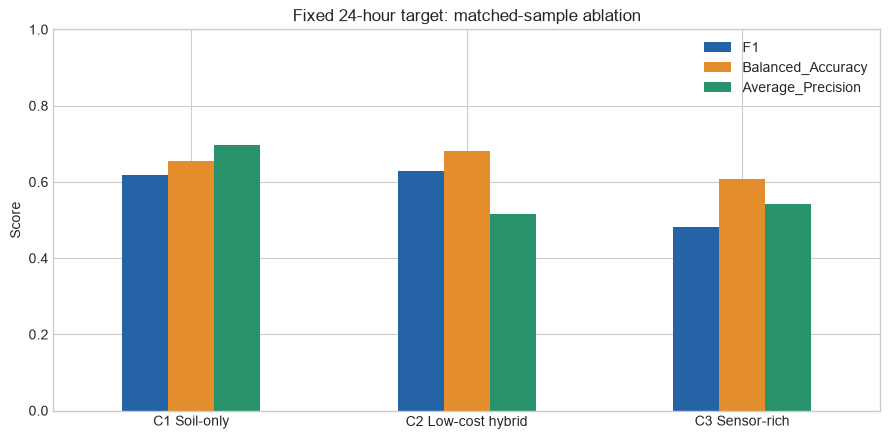

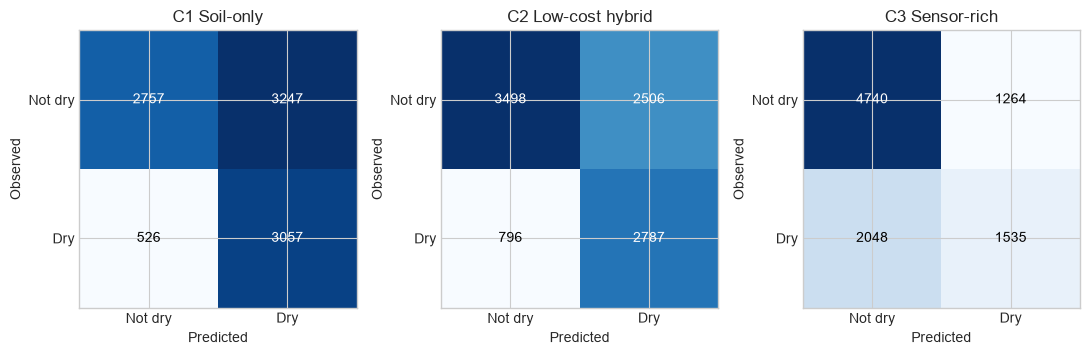

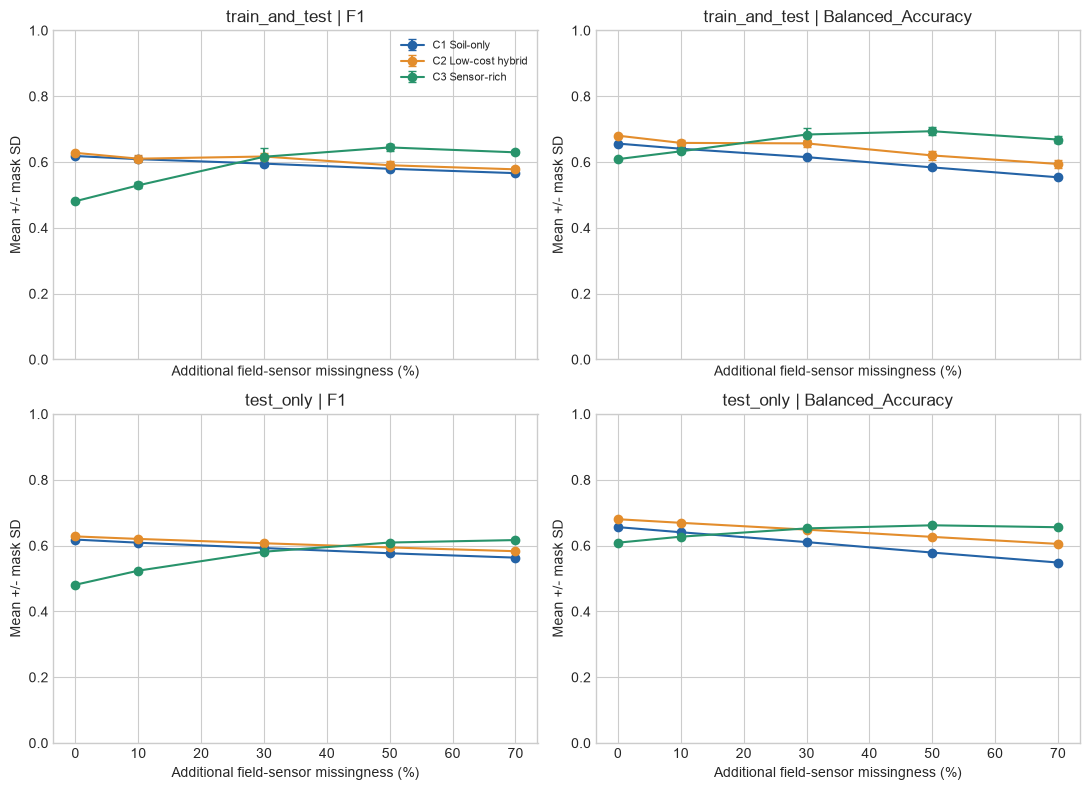

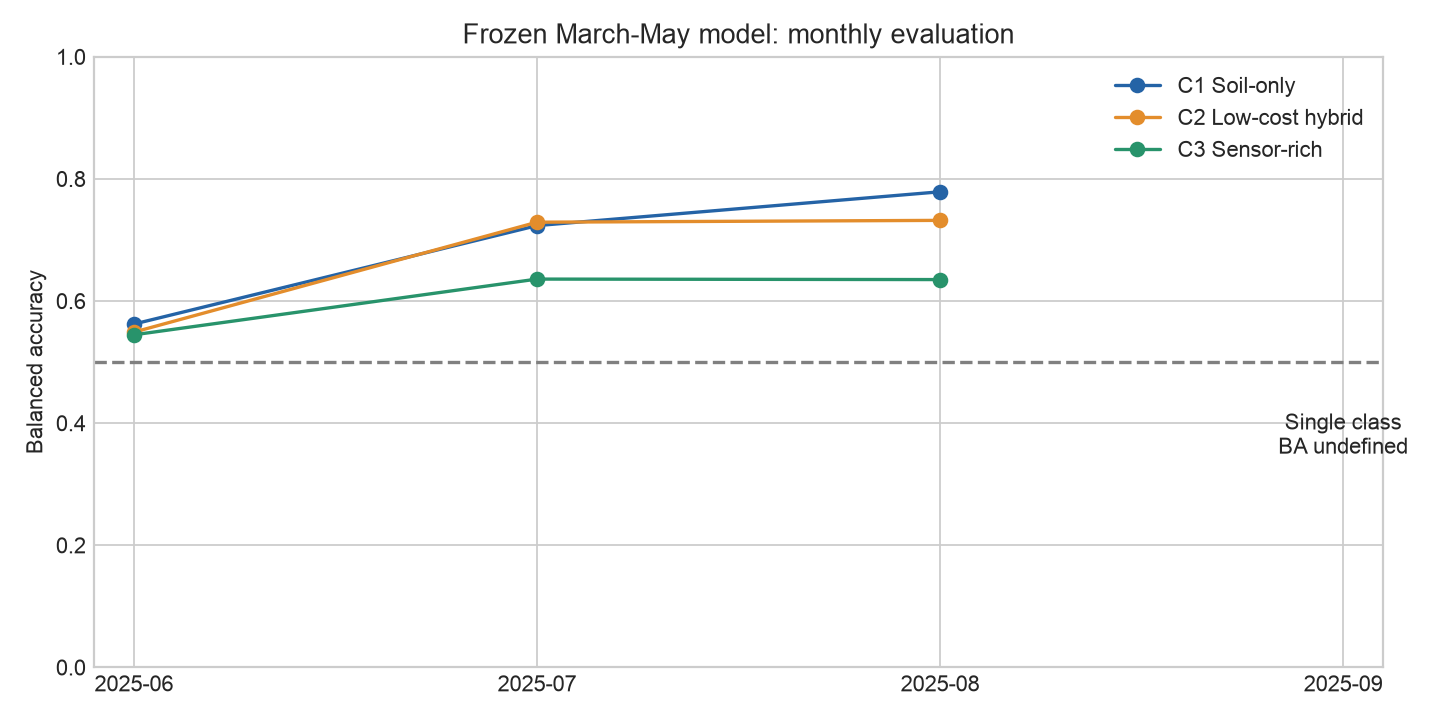

In [9]:
# 将实际指标保存成表图和中文结论，记录参数与数据来源。
plt.style.use('seaborn-v0_8-whitegrid')
v1_colors=['#2463a6','#e38d2c','#28936b']
fig,ax=plt.subplots(figsize=(9,4.5))
v1_ablation.set_index('configuration')[['F1','Balanced_Accuracy','Average_Precision']].plot.bar(ax=ax,color=v1_colors,rot=0)
ax.set_ylim(0,1); ax.set_title('Fixed 24-hour target: matched-sample ablation'); ax.set_ylabel('Score'); ax.set_xlabel('')
fig.tight_layout(); fig.savefig(v1_out/'ablation.png',dpi=160); plt.show()
fig,axes=plt.subplots(1,3,figsize=(11,3.5))
for ax,(_,r) in zip(axes,v1_ablation.iterrows()):
    cm=np.array([[r.TN,r.FP],[r.FN,r.TP]],dtype=int)
    ax.imshow(cm,cmap='Blues'); ax.set_title(r.configuration)
    ax.set_xticks([0,1],['Not dry','Dry']); ax.set_yticks([0,1],['Not dry','Dry'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Observed')
    for (i,j),v in np.ndenumerate(cm): ax.text(j,i,str(v),ha='center',va='center',color='white' if v>cm.max()/2 else 'black')
fig.tight_layout(); fig.savefig(v1_out/'confusion_matrices.png',dpi=160); plt.show()
fig,axes=plt.subplots(2,2,figsize=(11,8),sharex=True)
for row,scenario in enumerate(['train_and_test','test_only']):
    for col,metric in enumerate(['F1','Balanced_Accuracy']):
        ax=axes[row,col]
        for color,c in zip(v1_colors,v1_configs):
            g=v1_summary[(v1_summary.configuration==c)&(v1_summary.scenario==scenario)].sort_values('rate')
            ax.errorbar(g.rate*100,g[metric+'_mean'],yerr=g[metric+'_std'],marker='o',capsize=3,label=c,color=color)
        ax.set_title(scenario+' | '+metric); ax.set_ylim(0,1); ax.set_ylabel('Mean +/- mask SD'); ax.set_xlabel('Additional field-sensor missingness (%)')
axes[0,0].legend(fontsize=8); fig.tight_layout(); fig.savefig(v1_out/'missingness.png',dpi=160); plt.show()
fig,ax=plt.subplots(figsize=(9,4.5))
for color,c in zip(v1_colors,v1_configs):
    g=v1_temporal[v1_temporal.configuration==c]
    ax.plot(g.month,g.Balanced_Accuracy,marker='o',color=color,label=c)
ax.axhline(.5,color='gray',linestyle='--'); ax.set_ylim(0,1); ax.set_xticks(range(4), ['2025-06','2025-07','2025-08','2025-09']); ax.set_xlim(-.1,3.1); ax.text(3,.35,'Single class\nBA undefined',ha='center'); ax.set_title('Frozen March-May model: monthly evaluation'); ax.set_ylabel('Balanced accuracy'); ax.legend()
fig.tight_layout(); fig.savefig(v1_out/'temporal.png',dpi=160); plt.show()
v1_manifest={'protocol':'Research Technical Core v1','source_hashes':v1_hashes,
 'versions':{'python':platform.python_version(),'numpy':np.__version__,'pandas':pd.__version__,'sklearn':sklearn.__version__},
 'configs':v1_configs,'rf_params':v1_rf_params,'mask_seeds':v1_seeds,'mask_rates':v1_rates,
 'masked_features':v1_field,'target':'range-valid observed soil_moisture at decision+24 elapsed hours < zone threshold',
 'thresholds':v1_thresholds,'timezone':'Europe/Rome converted to UTC; nonexistent/ambiguous timestamps dropped',
 'train':'March-May; target before June 1','test':'June-July; target before August 1',
 'selection':'target available; same rows per configuration; input missingness imputed using training median',
 'flatline_rule':'same valid observed value for >=24h and >=12 observations; flag from detection onward, causal',
 'caveat':'Historical weather reanalysis/interpolation; retrospective research, not deployment validation',
 'elapsed_seconds':round(time.time()-v1_started,2)}
(v1_out/'run_manifest.json').write_text(json.dumps(v1_manifest,ensure_ascii=False,indent=2))
v1_known=[]
for _,r in v1_baselines.iterrows():
    v1_known.append(f"- 参照 {r.configuration}: F1={r.F1:.3f}, Balanced Accuracy={r.Balanced_Accuracy:.3f}, AP={r.Average_Precision:.3f}。")
for _,r in v1_ablation.iterrows():
    v1_known.append(f"- {r.configuration}: F1={r.F1:.3f}, Balanced Accuracy={r.Balanced_Accuracy:.3f}, AP={r.Average_Precision:.3f}, 预测正例率={r.predicted_positive_rate:.1%}。")
v1_report="""# Research Technical Core v1 — 实际运行结论

## Known（已核验）
- 旧 target 与清洗后后移144行一致；不能普遍解释为24小时。旧缺失曲线重复追加，不是两轮独立实验。
- 新核心以 UTC 精确24小时匹配有效观测标签，所有配置共享样本与标签；训练边界 purge，填补器仅 fit 训练数据。
"""+f'- 正式训练 {len(v1_train):,} 行，测试 {len(v1_test):,} 行；正例率分别 {v1_train.future_dry.mean():.1%}、{v1_test.future_dry.mean():.1%}。\n'+'\n'.join(v1_known)+"""

## Not Known（尚不能回答）
- 中国试点的阈值、灌溉时长、水量、节水收益、产量与作物安全效果。
- 哪个单独新增 feature 导致 C3 变化；需要后续逐项消融才能归因。
- 实际硬件成本与稳定性；尚未验证 BOM、设备通讯、真实连续故障。
- 跨农场、跨年泛化；历史结果不等于在线天气可用条件下的表现。

## Limitations（研究边界）
- 单农场、单季、分区阈值不同，RF 不输入 zone；标签是相对探头尺度，不等于通用含水率或缺水真值。
- 标签仅在未来传感器可用时存在，结果条件于该可用性；完整样本子集也有选择偏差。
- 范围过滤和因果24h不变值筛查仍不能排除所有漂移/尖峰，flatline筛查也可能误伤真实稳定状态；flatline_quality_audit.csv 记录剔除数量。时间聚合与历史天气插值不能证明在线因果可用性。
- 历史灌溉干预影响未来湿度，预测并非反事实灌溉需求。
- 10分钟样本和跨区天气高度相关；五次遮挡 SD 不是泛化置信区间，MCAR 不代表持续断网/MNAR。
- 主时间划分沿用既有研究探索，测试曾被查看；本版不调参，但不能称首次未见的独立验证。
- C3 混合天气服务、现场探头和操作日志；特征数量不是硬件数量或成本。
- 新旧数据清洗、目标、purge、mask定义均有变化，新旧分数变化不能单独归因于一个改动。

## 独立重跑
打开 research_core_v1.ipynb，重启内核后 Run All；或在项目内运行 src/research_core_v1.py。
依赖版本、源文件 SHA256、实验参数在 run_manifest.json；表格为 CSV，图为 PNG。
先核对 split_audit 和 fair_comparison_audit，再读 sensor_ablation/reference_baselines，最后读 missingness_summary 和 temporal_robustness。
本版完成的是可独立重跑的离线研究核心；硬件、Demo 与真实试点仍是后续工作。
"""
(v1_out/'Known_NotKnown_Limitations.md').write_text(v1_report)
print(v1_report)

## 本次运行结果怎么讲（2026-10-07）

- **复现对上了**：旧 ablation 的 F1 为 C1 0.4755、C2 0.2178、C3 0.2355，与原保存输出一致；截图缺失率 0% 的结果来自100棵树，不是这张200棵树的 ablation 表。原截图30行由15组重复追加产生。
- **正式问题已改正**：精确24小时目标、相同样本、训练边界 purge 和质量筛查后，训练5,923行，测试9,587行。新旧分数不能当作单一改动的“提升”。
- **主结果**：C1/C2/C3 的 F1 分别为0.618/0.628/0.481；Balanced Accuracy为0.656/0.680/0.609。C2略高于C1仅是这次切分的描述，没有显著性证据。AP反而C1较高，说明“谁最好”取决于评价目标。
- **重要参照**：当前状态延续的 F1=0.736、Balanced Accuracy=0.791，高于三种RF。它使用分区阈值；不能据此宣称严格同输入算法优劣，但足以阻止“复杂模型已验证有效”的过度结论。
- **样本选择敏感**：共同完整子集只有训练1,021行、测试5,345行，此时C1 F1=0.768，C2=0.478，C3=0.531。它们不可与主表直接比涨跌；样本群体改变了。
- **缺失不是简单单调降分**：train+test同时新增70%现场信息缺失时，五次F1均值约C1 0.566、C2 0.578、C3 0.630。C3部分指标上升只是这个遮挡/填补/分布组合下的现象，不能解释为断传感器更好，也不能据此选70%作部署方案。
- **时间变化明显**：6月正例率15.4%，7月46.0%；C2 Balanced Accuracy约0.549和0.729。9月剩余标签全为正例，Balanced Accuracy和PR指标记为NaN，不能用高F1证明双类识别稳定。
- **下一步方向**：先解释数据质量、当前状态参照与分区差异，再决定是否开展逐特征消融和真实试点采集；本版不继续堆模型。

### 你需要能独立回答的四个问题
1. 我们预测什么？——24小时后相对土壤读数是否低于该区历史阈值，不是直接预测中国地块该灌多少水。
2. 消融改变什么？——只换输入信息组，共同样本/标签/算法保持一致。
3. 缺失实验改变什么？——共同随机遮挡现场输入，标签不改，训练和测试缺失情境分开。
4. 什么时候不能下结论？——缺真值、只剩一种类别、疑似坏探头、跨农场迁移或因果节水效果都不能靠这张表证明。


## 8. 补查：探头“长时间不变”的筛查会不会改变结论？

刚才我们发现，Zone 3 有一大段读数一直是 0。为确认这条质量判断有没有左右主结果，我把实验做了两遍：

- 第一遍只剔除超出合理范围的读数。
- 第二遍还把连续一天、至少 12 次完全相同的读数标为“可能卡住”。

两遍的训练时间、测试日期、测试样本和正确答案都相同。结果：测试样本 **9,587 条**，两边答案完全一致；C1/C2/C3 的 F1 分别都是 **0.618、0.628、0.481**，Balanced Accuracy 分别都是 **0.656、0.680、0.609**。也就是说，**这条筛查没有改变本次 6–7 月总体结论**。

它标记最多的是 Zone 3：8,396 条；其他分区也有少量标记。说明数据质量问题真实存在，但不能单凭“数字重复”断定探头坏了。标记数字和逐配置对照表保存在项目的 results 文件夹中。

### 我们现在完成到哪里？

到这里，计划中的三类实验和这项清洗规则补查都完成了：比较三种信息组合、模拟传感器缺失、查看月份变化，并确认主结果不依赖本次长时间不变筛查。结论仍是：C2 在这次测试略高于 C1，C3 没有更好；简单的“明天大致跟今天一样”还比三种模型强。因此我们有了可信的第一版研究结果，但还不能说系统已经能指导田里的灌溉。

**怎么看结果**：下面代码会逐区输出被标记的条数和对照表。重新运行它只需运行这一格；完整重跑则运行上一节的 Research Technical Core v1。

In [ ]:
# 运行质量筛查对照，并把表格显示在 notebook 里。
import runpy
from IPython.display import display
qc_sensitivity = runpy.run_path(r'/Users/kaylasun/Downloads/low-cost-irrigation/src/quality_screen_sensitivity.py')
display(qc_sensitivity['result'].round(4))


## 9. 补查：C2 的领先可靠吗？模型胜过简单猜法吗？

**人话版**：C2 比 C1 的分数只高一点点。我们把测试日期按一周一组重复抽取 2,000 次，看看换一批测试周以后结果还稳不稳。

**结果**：C2 的 F1 平均只比 C1 高 0.004，可能的差异范围是 -0.032 到 +0.043；Balanced Accuracy 平均高 0.014，范围是 -0.031 到 +0.053。这两个范围都包含“没有差别”，所以现在不能说 C2 确实更好。

“明天跟今天差不多”的简单猜法，这次总分比三个模型高；但反复抽取测试周以后，范围很宽。现有 60 天不足以宣布哪一种在其他季节、其他地块也会赢。

分区差异很大：Zone 5 只有 20 个偏干样本，分数容易不稳定；Zone 2 有 1,311 个偏干样本，占本区测试记录的 85%。因此总分不能代表每个分区。

下面的表格可以逐区查看。重复抽样的区间只是帮助我们判断这次结果稳不稳，不是正式证明，也不能代表别的农场。

In [1]:
# 显示分区结果，以及“C2-C1”与“模型-简单猜法”的重复抽样差异。
from pathlib import Path
import pandas as pd
from IPython.display import display
v1_out = Path('/Users/kaylasun/Downloads/low-cost-irrigation/outputs/research_core_v1')
by_zone = pd.read_csv(v1_out / 'model_vs_persistence_by_zone.csv')
block_check = pd.read_csv(v1_out / 'model_comparison_block_bootstrap.csv')
display(by_zone.round(4))
display(block_check.round(4))


,scope,configuration,n,positive,positive_rate,F1,Balanced_Accuracy
0,Zone 1,C1 Soil-only,2603,1287,0.4944,0.7189,0.6248
1,Zone 1,C2 Low-cost hybrid,2603,1287,0.4944,0.7197,0.6769
2,Zone 1,C3 Sensor-rich,2603,1287,0.4944,0.3846,0.4940
3,Zone 1,Current-state persistence,2603,1287,0.4944,0.8170,0.8414
4,Zone 2,C1 Soil-only,1535,1311,0.8541,0.9227,0.5186
5,Zone 2,C2 Low-cost hybrid,1535,1311,0.8541,0.8917,0.6192
6,Zone 2,C3 Sensor-rich,1535,1311,0.8541,0.6751,0.6672
7,Zone 2,Current-state persistence,1535,1311,0.8541,0.8131,0.8169
8,Zone 3,C1 Soil-only,515,180,0.3495,0.5835,0.6223
9,Zone 3,C2 Low-cost hybrid,515,180,0.3495,0.6770,0.7445


,comparison,metric,mean,lower,upper,fraction_positive
0,C1 - persistence,Balanced_Accuracy,-0.0989,-0.2148,0.1220,0.1430
1,C1 - persistence,F1,-0.0728,-0.2480,0.2040,0.2100
2,C2 - C1,Balanced_Accuracy,0.0139,-0.0314,0.0526,0.7260
3,C2 - C1,F1,0.0044,-0.0316,0.0429,0.5790
4,C2 - persistence,Balanced_Accuracy,-0.0850,-0.2117,0.1237,0.1775
5,C2 - persistence,F1,-0.0684,-0.2554,0.2088,0.2415
6,C3 - persistence,Balanced_Accuracy,-0.1457,-0.2842,0.1144,0.1270
7,C3 - persistence,F1,-0.1975,-0.4183,0.2117,0.1380
